<div style="background:linear-gradient(135deg,#ffffff,#fffdfd);color:#5c1d0c;padding:28px;border-left:8px solid #E24307;border-radius:14px;font-family:'Segoe UI',sans-serif;box-shadow:0px 4px 16px rgba(0,0,0,0.12);">
  <div style="display:flex;align-items:center;gap:16px;margin-bottom:16px;">
    <img src="data/logo-swift.png" alt="Logo Swift" style="height:52px;">
    <h1 style="color:#E24307;margin:0;font-size:28px;letter-spacing:1px;">PROJETO NPS SWIFT — ENTREGA 1</h1>
  </div>
  <hr style="border:0;border-top:2px solid #f0d0c8;margin:12px 0;">
  <p style="margin:6px 0;font-size:14px;"><b>Membros:</b> Bruna Carvalho Cardoso | Giovanne Antony Bahia Torquato | Kaique Moreira Arantes De Souza | Leticia Nascimento da Silva | Sofia Bonini Pinto</p>
  <p style="margin:6px 0;font-size:14px;"><b>Data Entrega:</b> 09/06/2026</p>
  <p style="margin:12px 0 0 0;font-size:13px;color:#7e2200;">Objetivo: construir modelos de NLP para análise automática de comentários de NPS da Swift, identificando sentimento e categoria. Esta entrega cobre EDA, definição de categorias e definição da análise de sentimento.</p>
</div>

---
### Índice
1. [Pré-Processamento](#pre)
2. [EDA — Análise Exploratória](#eda)
   - 1.1 Distribuição do NPS e comentários
   - 1.2 Cobertura por loja
   - 1.3 Características do texto
   - 1.4 Qualidade e ruído
   - 1.5 Análise temporal
   - 1.6 Análise léxica por faixa de nota
3. [Tópico 2 — Definição de Categorias](#t2)
   - Método A: Clusterização LDA
   - 2.1 Tabela de categorias
   - 2.2 Decisões obrigatórias
   - 2.3 Amostra anotada e Kappa de Cohen
4. [Tópico 3 — Definição da Análise de Sentimento](#t3)
   - 3.1 Granularidade dos sentimentos
   - 3.2 Nota vs. texto
   - 3.3 Comentários mistos
---

<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 1 — PRÉ-PROCESSAMENTO</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 1. Imports & Configurações</div>

In [38]:
import pandas as pd
import numpy as np
import re
import warnings
import unicodedata
from pathlib import Path
import emoji

warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Estatísticas
from scipy import stats

# NLP
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')

CORES       = {'promotor': '#2ecc71', 'neutro': '#f39c12', 'detrator': '#e74c3c'}
CORES_FLAG  = {'REGULAR': '#3498db', 'TOCADORA': '#9b59b6'}
STOPWORDS_PT = set(stopwords.words('portuguese'))

# Mapeamento de dias da semana (evita dependência de locale do SO)
DIAS_PT = {0:'Segunda',1:'Terça',2:'Quarta',3:'Quinta',4:'Sexta',5:'Sábado',6:'Domingo'}

# Seed global para reprodutibilidade
import random
random.seed(42)
np.random.seed(42)

# Registro de versões
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'sklearn : ', end='')
import sklearn; print(sklearn.__version__)
print('[OK] Imports carregados')

pandas  : 3.0.3
numpy   : 2.4.6
sklearn : 1.6.1
[OK] Imports carregados


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 2. Carregamento dos Dados</div>

In [39]:
PATH_AVALIACOES = 'data/dados_nps_swift.xlsx'
PATH_TRANSACOES = 'data/dados_transacoes_lojas.xlsx'

df_aval  = pd.read_excel(PATH_AVALIACOES)
df_trans = pd.read_excel(PATH_TRANSACOES)

print(f'Avaliações : {df_aval.shape[0]:,} linhas | {df_aval.shape[1]} colunas')
print(f'Transações : {df_trans.shape[0]:,} linhas | {df_trans.shape[1]} colunas')

Avaliações : 240,352 linhas | 7 colunas
Transações : 3,645 linhas | 6 colunas


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 3. Inspeção Inicial</div>

In [40]:
print('=== AVALIAÇÕES — Primeiras linhas ===')
display(df_aval.head(5))

print('\n=== AVALIAÇÕES — Info ===')
df_aval.info()

print('\n=== AVALIAÇÕES — Nulos e % ===')
nulos = pd.DataFrame({
    'Nulos': df_aval.isnull().sum(),
    '%': (df_aval.isnull().mean() * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0])

print('\n=== AVALIAÇÕES — Estatísticas descritivas ===')
display(df_aval.describe(include='all'))

print('\n=== TRANSAÇÕES — Primeiras linhas ===')
display(df_trans.head(3))
df_trans.info()

=== AVALIAÇÕES — Primeiras linhas ===


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
0,2025-01-01,promotor,2025-01-01 00:00:00,L5001-RIBEIRAO PRETO (0217),6,-,REGULAR
1,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,REGULAR
2,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",REGULAR
3,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Melhorar o preço!,REGULAR
4,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,-,REGULAR



=== AVALIAÇÕES — Info ===
<class 'pandas.DataFrame'>
RangeIndex: 240352 entries, 0 to 240351
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Mes Ano         240352 non-null  datetime64[us]
 1   classificacao   240352 non-null  str           
 2   Data Avaliação  240352 non-null  object        
 3   CentroNv2       240352 non-null  str           
 4   qtd_clientes    240352 non-null  int64         
 5   Comentario      240352 non-null  str           
 6   Flag            239595 non-null  str           
dtypes: datetime64[us](1), int64(1), object(1), str(4)
memory usage: 33.0+ MB

=== AVALIAÇÕES — Nulos e % ===


,Nulos,%
Flag,757,0.31



=== AVALIAÇÕES — Estatísticas descritivas ===


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
count,240352,240352,240352,240352,240352.00,240352,239595
unique,NaN,4,504,228,NaN,114609,2
top,NaN,promotor,2025-06-03 00:00:00,L5230-LARGO DO MACHADO,NaN,-,REGULAR
freq,NaN,196526,1114,2544,NaN,112010,183135
mean,2025-08-28 21:40:41.179603,NaN,NaN,NaN,2.01,NaN,NaN
min,2025-01-01 00:00:00,NaN,NaN,NaN,0.00,NaN,NaN
25%,2025-05-01 00:00:00,NaN,NaN,NaN,1.00,NaN,NaN
50%,2025-09-01 00:00:00,NaN,NaN,NaN,1.00,NaN,NaN
75%,2026-01-01 00:00:00,NaN,NaN,NaN,2.00,NaN,NaN
max,2026-05-01 00:00:00,NaN,NaN,NaN,52.00,NaN,NaN



=== TRANSAÇÕES — Primeiras linhas ===


,CentroNv2,Mes Ano,Regiao_IM,Municipio,UF,Transações
0,L5001-RIBEIRAO PRETO (0217),2025-01-01,Interior,RIBEIRÃO PRETO,SP,9738
1,L5002-ALPHAVILLE (0290),2025-01-01,RMSP,BARUERI,SP,7890
2,L5003-LINS (0340),2025-01-01,Interior,LINS,SP,7111


<class 'pandas.DataFrame'>
RangeIndex: 3645 entries, 0 to 3644
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   CentroNv2   3645 non-null   str           
 1   Mes Ano     3645 non-null   datetime64[us]
 2   Regiao_IM   3645 non-null   str           
 3   Municipio   3645 non-null   str           
 4   UF          3645 non-null   str           
 5   Transações  3645 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 309.7 KB


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 4. Limpeza e Padronização</div>

In [41]:
# ── 4.1 Cópias de trabalho ──────────────────────────────────────────────────
df   = df_aval.copy()
df_t = df_trans.copy()

# ── 4.2 Renomear colunas (snake_case) ────────────────────────────────────────
rename_aval = {
    'Mes Ano'        : 'mes_ano',
    'classificacao'  : 'classificacao',
    'Data Avaliacao' : 'data_avaliacao',
    'Data Avaliação' : 'data_avaliacao',
    'CentroNv2'      : 'centro_nv2',
    'qtd_clientes'   : 'qtd_clientes',
    'Comentario'     : 'comentario',
    'Comentário'     : 'comentario',
    'Flag'           : 'flag',
}
rename_trans = {
    'CentroNv2' : 'centro_nv2',
    'Mes Ano'   : 'mes_ano',
    'Regiao_IM' : 'regiao',
    'Municipio' : 'municipio',
    'UF'        : 'uf',
    'Transacoes': 'transacoes',
    'Transações': 'transacoes',
}

df   = df.rename(columns=rename_aval)
df_t = df_t.rename(columns=rename_trans)

print('Colunas avaliações:', list(df.columns))
print('Colunas transações:', list(df_t.columns))

Colunas avaliações: ['mes_ano', 'classificacao', 'data_avaliacao', 'centro_nv2', 'qtd_clientes', 'comentario', 'flag']
Colunas transações: ['centro_nv2', 'mes_ano', 'regiao', 'municipio', 'uf', 'transacoes']


In [42]:
# ── 4.3 Padronizar strings ──────────────────────────────────────────────────
for col in ['classificacao', 'flag']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

for col in ['centro_nv2']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

df_t['centro_nv2'] = df_t['centro_nv2'].astype(str).str.strip().str.upper()

print('Classificações únicas :', sorted(df['classificacao'].dropna().unique()))
print('Flags únicas          :', sorted(df['flag'].dropna().unique()))

Classificações únicas : ['-', 'detrator', 'neutro', 'promotor']
Flags únicas          : ['regular', 'tocadora']


In [43]:
# ── 4.4 Tratar flag inválida (nan) ──────────────────────────────────────────
# 757 registros com flag=nan identificados. Estratégia: remover pois não é
# possível atribuir ao grupo REGULAR ou TOCADORA sem informação.
before = len(df)
flags_validas = {'regular', 'tocadora'}
df = df[df['flag'].isin(flags_validas)].copy()
print(f'Removidos por flag inválida: {before - len(df)} registros')
print(f'Shape após filtro de flag  : {df.shape}')

Removidos por flag inválida: 757 registros
Shape após filtro de flag  : (239595, 7)


In [44]:
# ── 4.5 Remover classificação inválida ('-') e qtd_clientes <= 0 ────────────
# Registros com classificação '-' têm qtd_clientes=0: redundante, mas filtramos
# por qtd_clientes para capturar ambos os casos.
before = len(df)
df['qtd_clientes'] = pd.to_numeric(df['qtd_clientes'], errors='coerce')
df = df[df['qtd_clientes'] > 0].dropna(subset=['qtd_clientes']).copy()
print(f'Removidos por qtd_clientes <= 0: {before - len(df)} registros')
print(f'Classificações restantes: {sorted(df["classificacao"].unique())}')

Removidos por qtd_clientes <= 0: 452 registros
Classificações restantes: ['detrator', 'neutro', 'promotor']


In [45]:
# ── 4.6 Tratar transações ────────────────────────────────────────────────────
if df_t['transacoes'].dtype == object:
    df_t['transacoes'] = (
        df_t['transacoes'].astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
df_t['transacoes'] = pd.to_numeric(df_t['transacoes'], errors='coerce')

# ── 4.7 Duplicatas ───────────────────────────────────────────────────────────
# Removemos ANTES de qualquer outra operação para garantir contagens corretas
dup_aval  = df.duplicated().sum()
dup_trans = df_t.duplicated().sum()
print(f'Duplicatas exatas em avaliações : {dup_aval}')
print(f'Duplicatas exatas em transações : {dup_trans}')
df   = df.drop_duplicates().copy()
df_t = df_t.drop_duplicates().copy()

print(f'\nShape avaliações após limpeza: {df.shape}')
print(f'Shape transações após limpeza : {df_t.shape}')
print('[OK] Limpeza concluída')

Duplicatas exatas em avaliações : 0
Duplicatas exatas em transações : 0

Shape avaliações após limpeza: (239143, 7)
Shape transações após limpeza : (3645, 6)
[OK] Limpeza concluída


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 5. Tratamento de Datas</div>

In [46]:
# ── 5.1 data_avaliacao → datetime ────────────────────────────────────────────
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], dayfirst=True, errors='coerce')
print(f'Datas inválidas (NaT): {df["data_avaliacao"].isnull().sum()}')

# ── 5.2 Componentes temporais ─────────────────────────────────────────────────
df['ano']       = df['data_avaliacao'].dt.year
df['mes']       = df['data_avaliacao'].dt.month
df['trimestre'] = df['data_avaliacao'].dt.quarter
df['semana_ano']= df['data_avaliacao'].dt.isocalendar().week.astype('Int64')
df['dia_semana']= df['data_avaliacao'].dt.dayofweek

df['dia_semana_nome'] = df['data_avaliacao'].dt.dayofweek.map(DIAS_PT)

# Period para ordenação correta em gráficos
df['mes_ano_dt'] = df['data_avaliacao'].dt.to_period('M')

# Transações: mes_ano → Period
df_t['mes_ano_dt'] = pd.to_datetime(df_t['mes_ano'], errors='coerce').dt.to_period('M')

# ── 5.3 Sanity check ─────────────────────────────────────────────────────────
df['_check'] = pd.to_datetime(df['mes_ano'], errors='coerce').dt.to_period('M')
inconsistentes = df[df['mes_ano_dt'].notna() & df['_check'].notna() & (df['mes_ano_dt'] != df['_check'])]
print(f'Registros com data fora do mes_ano: {len(inconsistentes)}')
df = df.drop(columns=['_check'])

print('[OK] Datas processadas')
display(df[['data_avaliacao','ano','mes','dia_semana_nome','trimestre','mes_ano_dt']].head(3))

Datas inválidas (NaT): 0
Registros com data fora do mes_ano: 0
[OK] Datas processadas


,data_avaliacao,ano,mes,dia_semana_nome,trimestre,mes_ano_dt
0,2025-01-01,2025,1,Quarta,1,2025-01
1,2025-01-02,2025,1,Quinta,1,2025-01
2,2025-01-02,2025,1,Quinta,1,2025-01


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 6. Tratamento de Texto (Comentários)</div>

In [47]:
# ── 6.1 Identificar comentários ausentes / placeholder ───────────────────────
PLACEHOLDERS = {'-', 'nan', 'none', '', 'n/a', 'nenhum', 'sem comentario',
                'sem comentário', 'nada', 'ok'}

df['comentario_raw'] = df['comentario'].astype(str).str.strip()
df['tem_comentario'] = ~df['comentario_raw'].str.lower().isin(PLACEHOLDERS)

print(f'COM comentário real : {df["tem_comentario"].sum():,}')
print(f'SEM comentário real : {(~df["tem_comentario"]).sum():,}')
print(f'Taxa de comentários : {df["tem_comentario"].mean()*100:.1f}%')

COM comentário real : 127,933
SEM comentário real : 111,210
Taxa de comentários : 53.5%


In [48]:
# ── 6.2 Função de limpeza — PRESERVA ACENTOS ───────────────
# Acentos removidos corrompem embeddings BERT/BERTimbau. A limpeza básica
# apenas normaliza espaços, pontuação e números, mantendo texto legível.
def limpar_texto(texto: str) -> str:
    """Limpeza básica para NLP — preserva acentos para compatibilidade com modelos BERT."""
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', ' ', texto)   # Remove pontuação, preserva letras acentuadas
    texto = re.sub(r'\b\d+\b', '', texto)     # Remove números isolados
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Versão sem acento — usada APENAS no CountVectorizer do LDA (não para BERT)
def limpar_texto_sem_acento(texto: str) -> str:
    """Versão sem acentos — usar SOMENTE para LDA/TF-IDF, nunca para transformers."""
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return limpar_texto(texto)

df['comentario_limpo'] = df.apply(
    lambda r: limpar_texto(r['comentario_raw']) if r['tem_comentario'] else '',
    axis=1
)

print('[OK] Texto limpo (acentos preservados)')
display(df[df['tem_comentario']][['comentario_raw','comentario_limpo']].head(5))

[OK] Texto limpo (acentos preservados)


,comentario_raw,comentario_limpo
1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,bastante falta de produto talvez pela data mas não tinha muita coisa principalmente bovino
2,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",estrutura excelente mas os peços deveriam ser melhores ou equivalentes aos mercados de carnes
3,Melhorar o preço!,melhorar o preço
6,Alguns produtos com porções menores.,alguns produtos com porções menores
7,Estão de parabéns,estão de parabéns


In [49]:
# ── 6.3 Detecção de spam e comentários inválidos ────────────
# Aplicado sobre comentario_limpo (já processado), não sobre raw
# Lógica de emojis: usa lib `emoji` para remoção e detecção

def is_spam(text: str) -> bool:
    text = str(text).strip()
    if len(text) == 0:
        return True
    text_sem_emoji = emoji.replace_emoji(text, replace='').strip()
    if len(text_sem_emoji) == 0:
        return True   # Só emojis = sem informação textual
    alpha = sum(c.isalpha() for c in text_sem_emoji)
    return (
        alpha / len(text_sem_emoji) < 0.40
        or bool(re.match(r'\A(.)\1{4,}\Z', text_sem_emoji))
    )

# Aplicar sobre comentario_limpo (texto já processado)
mask_spam = df['comentario_limpo'].apply(is_spam)
df.loc[mask_spam & df['tem_comentario'], 'tem_comentario'] = False

print(f'Comentários marcados como spam/inválidos: {mask_spam.sum():,}')
print(f'Comentários válidos após filtro          : {df["tem_comentario"].sum():,}')

Comentários marcados como spam/inválidos: 111,234
Comentários válidos após filtro          : 127,909


Média de palavras (com sw)    : 15.9
Média de palavras (sem sw)    : 9.3
Mediana (com sw)              : 9


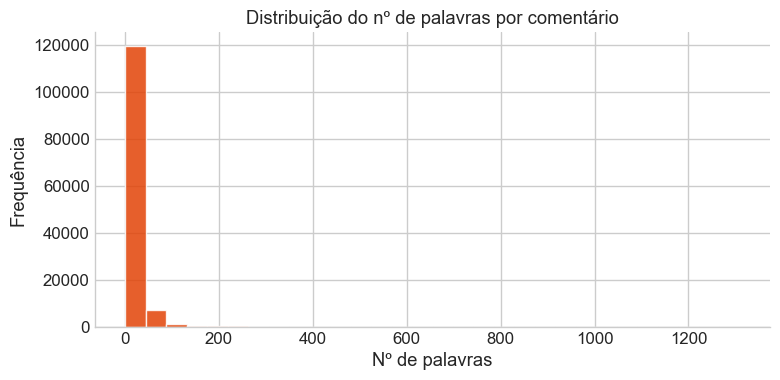

In [50]:
# ── 6.4 Métricas de texto ────────────────────────────────────────────────────
df['qtd_chars']    = df['comentario_limpo'].str.len()
df['qtd_palavras'] = df['comentario_limpo'].str.split().str.len().fillna(0).astype(int)

# ── 6.5 Remover stopwords — coluna separada ───────────────────────────────────
def remover_stopwords(texto: str) -> str:
    if not texto:
        return ''
    return ' '.join(w for w in texto.split() if w not in STOPWORDS_PT)

df['comentario_sem_sw'] = df['comentario_limpo'].apply(remover_stopwords)

# Contagem de palavras APÓS remover stopwords — usada no filtro de tópicos
# filtro usa texto pós-stopwords, que reflete o que será entregue ao modelo
df['qtd_palavras_sem_sw'] = df['comentario_sem_sw'].str.split().str.len().fillna(0).astype(int)

comentarios_validos = df[df['tem_comentario']]
print(f'Média de palavras (com sw)    : {comentarios_validos["qtd_palavras"].mean():.1f}')
print(f'Média de palavras (sem sw)    : {comentarios_validos["qtd_palavras_sem_sw"].mean():.1f}')
print(f'Mediana (com sw)              : {comentarios_validos["qtd_palavras"].median():.0f}')

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(comentarios_validos['qtd_palavras'], bins=30, color='#E24307', edgecolor='white', alpha=0.85)
ax.set_title('Distribuição do nº de palavras por comentário')
ax.set_xlabel('Nº de palavras')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

In [51]:
# ── 6.6 Criar tipo_cliente (schema CLAUDE.md) ────────────────────────────────
TIPO_MAP = {'promotor': 'Promotor', 'neutro': 'Neutro', 'detrator': 'Detrator'}
df['tipo_cliente'] = df['classificacao'].map(TIPO_MAP)

print('tipo_cliente criado:', df['tipo_cliente'].value_counts().to_dict())

tipo_cliente criado: {'Promotor': 195872, 'Neutro': 27963, 'Detrator': 15308}


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 7. Merge das Bases</div>

In [52]:
lojas_aval  = set(df['centro_nv2'].unique())
lojas_trans = set(df_t['centro_nv2'].unique())
print(f'Lojas em avaliações : {len(lojas_aval)}')
print(f'Lojas em transações : {len(lojas_trans)}')
print(f'Lojas em comum      : {len(lojas_aval & lojas_trans)}')
print(f'Só em transações    : {lojas_trans - lojas_aval}')

periodos_aval  = set(df['mes_ano_dt'].dropna().unique())
periodos_trans = set(df_t['mes_ano_dt'].dropna().unique())
sem_cobertura  = periodos_aval - periodos_trans
print(f'\nPeríodos em avaliações : {len(periodos_aval)}')
print(f'Períodos sem transação  : {sem_cobertura}  ← registros terão transacoes=NaN')

df_merge = df.merge(
    df_t[['centro_nv2','mes_ano_dt','transacoes','regiao','municipio','uf']],
    on=['centro_nv2','mes_ano_dt'],
    how='left'
)
cobertura = df_merge['transacoes'].notna().mean() * 100
print(f'\nMerge concluído: {df_merge.shape}')
print(f'Cobertura de transações: {cobertura:.1f}%')

Lojas em avaliações : 227
Lojas em transações : 229
Lojas em comum      : 227
Só em transações    : {'L5060-RIVIERA (1300)', 'L5293-DIADEMA'}

Períodos em avaliações : 17
Períodos sem transação  : {Period('2026-05', 'M')}  ← registros terão transacoes=NaN

Merge concluído: (239143, 26)
Cobertura de transações: 96.3%


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Decisão aplicada — Cobertura de transações:</b><br>
O período <code>2026-05</code> (último mês da base) não possui dados de transações na planilha de transações. Todos os registros desse período terão <code>transacoes = NaN</code> após o merge.<br><br>
<b>Estratégia:</b> os registros <b>não são removidos</b> — o NPS é válido independentemente do volume de transações. A coluna <code>transacoes</code> será usada apenas como informação complementar no dashboard. Análises que dependam de <code>transacoes</code> (ex: taxa de resposta) excluirão automaticamente os registros com NaN via <code>dropna()</code> ou <code>notna()</code>.
</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 8. Feature Engineering</div>

In [53]:
# ── 8.1 Score NPS por linha ──────────────────────────────────────────────────
NPS_SCORE_MAP = {'promotor': 100, 'neutro': 0, 'detrator': -100}
df_merge['nps_score']    = df_merge['classificacao'].map(NPS_SCORE_MAP)
df_merge['n_promotores'] = np.where(df_merge['classificacao']=='promotor', df_merge['qtd_clientes'], 0)
df_merge['n_neutros']    = np.where(df_merge['classificacao']=='neutro',   df_merge['qtd_clientes'], 0)
df_merge['n_detratores'] = np.where(df_merge['classificacao']=='detrator', df_merge['qtd_clientes'], 0)
print('[OK] Features NPS criadas')

[OK] Features NPS criadas


In [54]:
# ── 8.2 NPS consolidado por loja × mês ───────────────────────────────────────
nps_loja_mes = (
    df_merge
    .groupby(['centro_nv2','mes_ano_dt','flag','regiao','municipio','uf'])
    .agg(
        total_respostas = ('qtd_clientes',   'sum'),
        n_promotores    = ('n_promotores',   'sum'),
        n_neutros       = ('n_neutros',      'sum'),
        n_detratores    = ('n_detratores',   'sum'),
        transacoes      = ('transacoes',     'first'),
    )
    .reset_index()
)
nps_loja_mes['pct_promotores'] = nps_loja_mes['n_promotores'] / nps_loja_mes['total_respostas'] * 100
nps_loja_mes['pct_detratores'] = nps_loja_mes['n_detratores'] / nps_loja_mes['total_respostas'] * 100
nps_loja_mes['nps']            = nps_loja_mes['pct_promotores'] - nps_loja_mes['pct_detratores']
nps_loja_mes['taxa_resposta_pct'] = (nps_loja_mes['total_respostas'] / nps_loja_mes['transacoes'] * 100).round(2)

print(f'Tabela NPS por loja×mês: {nps_loja_mes.shape}')
display(nps_loja_mes.head(3))

Tabela NPS por loja×mês: (3621, 15)


,centro_nv2,mes_ano_dt,flag,regiao,municipio,uf,total_respostas,n_promotores,n_neutros,n_detratores,transacoes,pct_promotores,pct_detratores,nps,taxa_resposta_pct
0,L5001-RIBEIRAO PRETO (0217),2025-01,regular,Interior,RIBEIRÃO PRETO,SP,243,212,22,9,9738.00,87.24,3.70,83.54,2.50
1,L5001-RIBEIRAO PRETO (0217),2025-02,regular,Interior,RIBEIRÃO PRETO,SP,126,109,11,6,9074.00,86.51,4.76,81.75,1.39
2,L5001-RIBEIRAO PRETO (0217),2025-03,regular,Interior,RIBEIRÃO PRETO,SP,148,135,9,4,9801.00,91.22,2.70,88.51,1.51


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 9. Detecção de Outliers</div>

Outliers IQR    : 37,032 (15.5%)
Outliers Z-Score: 5,180 (2.2%)


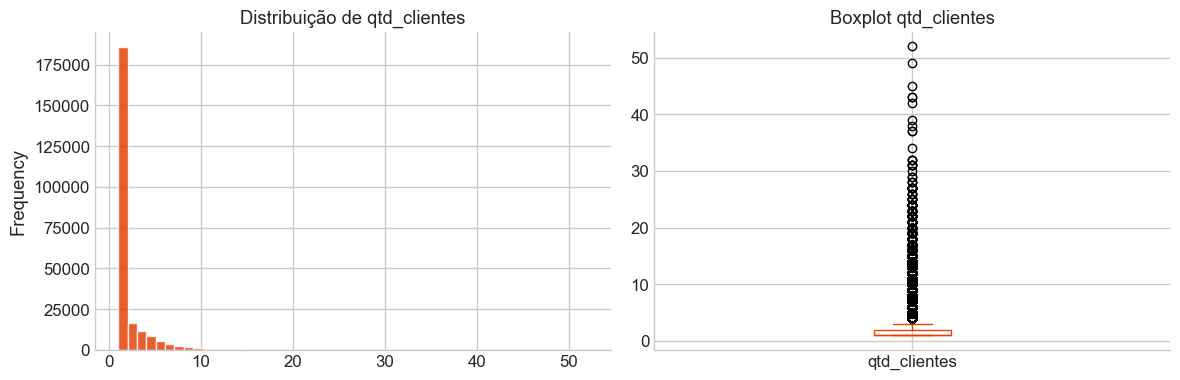

count   239143.00
mean         2.02
std          2.13
min          1.00
25%          1.00
50%          1.00
75%          2.00
95%          6.00
99%         11.00
max         52.00
Name: qtd_clientes, dtype: float64


In [55]:
# ── 9.1 IQR ──────────────────────────────────────────────────────────────────
Q1 = df_merge['qtd_clientes'].quantile(0.25)
Q3 = df_merge['qtd_clientes'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = max(0, Q1 - 1.5 * IQR)

df_merge['outlier_iqr'] = (
    (df_merge['qtd_clientes'] < lim_inf) |
    (df_merge['qtd_clientes'] > lim_sup)
)

# ── 9.2 Z-Score ───────────────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df_merge['qtd_clientes'].fillna(0)))
df_merge['outlier_zscore'] = z_scores > 3

# Colunas de outliers
print(f'Outliers IQR    : {df_merge["outlier_iqr"].sum():,} ({df_merge["outlier_iqr"].mean()*100:.1f}%)')
print(f'Outliers Z-Score: {df_merge["outlier_zscore"].sum():,} ({df_merge["outlier_zscore"].mean()*100:.1f}%)')

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df_merge['qtd_clientes'].plot.hist(bins=50, ax=axes[0], color='#E24307', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição de qtd_clientes')
df_merge['qtd_clientes'].plot.box(ax=axes[1], color='#E24307')
axes[1].set_title('Boxplot qtd_clientes')
plt.tight_layout(); plt.show()
print(df_merge['qtd_clientes'].describe(percentiles=[.25,.5,.75,.95,.99]))

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 10. Exportação das Bases Tratadas</div>

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Arquivos gerados (contratos do CLAUDE.md):</b><br>
• <code>df_avaliacoes_tratado.parquet</code> — base principal limpa (schema completo)<br>
• <code>df_nps_loja_mes.parquet</code> — NPS agregado por loja × mês<br>
• <code>df_comentarios_nlp.parquet</code> — entrada para todos os módulos NLP<br>
• <code>base_final.csv</code> — backup completo em CSV
</div>

In [56]:
# ── 10.1 df_avaliacoes_tratado — schema completo conforme CLAUDE.md ──────────
colunas_avaliacao = [
    'mes_ano_dt', 'classificacao', 'tipo_cliente', 'data_avaliacao',
    'centro_nv2', 'qtd_clientes', 'comentario', 'flag',
    'ano', 'mes', 'trimestre', 'semana_ano', 'dia_semana', 'dia_semana_nome',
    'comentario_raw', 'tem_comentario', 'comentario_limpo',
    'comentario_sem_sw', 'qtd_chars', 'qtd_palavras', 'qtd_palavras_sem_sw',
    'nps_score', 'n_promotores', 'n_neutros', 'n_detratores',
    'outlier_iqr', 'outlier_zscore',
    'transacoes', 'regiao', 'municipio', 'uf',
]
# Apenas colunas que existem
colunas_avaliacao = [c for c in colunas_avaliacao if c in df_merge.columns]
df_avaliacoes_tratado = df_merge[colunas_avaliacao].copy()

# Converter Period para string antes de exportar parquet
df_export = df_avaliacoes_tratado.copy()
df_export['mes_ano_dt'] = df_export['mes_ano_dt'].astype(str)

df_export.to_parquet('data/df_avaliacoes_tratado.parquet', index=False)
print(f'[OK] df_avaliacoes_tratado.parquet : {df_export.shape}')

# ── 10.2 df_nps_loja_mes ─────────────────────────────────────────────────────
nps_export = nps_loja_mes.copy()
nps_export['mes_ano_dt'] = nps_export['mes_ano_dt'].astype(str)
nps_export.to_parquet('data/df_nps_loja_mes.parquet', index=False)
print(f'[OK] df_nps_loja_mes.parquet       : {nps_export.shape}')

# ── 10.3 df_comentarios_nlp — entrada para todos os módulos NLP ──────────────
# Schema: centro_nv2, data_avaliacao, flag, tipo_cliente,
#         comentario, comentario_limpo, n_palavras, n_chars
df_comentarios_nlp = df_merge[df_merge['tem_comentario']].copy()
df_comentarios_nlp = df_comentarios_nlp[[
    'centro_nv2', 'data_avaliacao', 'flag', 'tipo_cliente',
    'comentario', 'comentario_limpo', 'qtd_palavras', 'qtd_chars'
]].rename(columns={'qtd_palavras': 'n_palavras', 'qtd_chars': 'n_chars'})

nlp_export = df_comentarios_nlp.copy()
nlp_export.to_parquet('data/df_comentarios_nlp.parquet', index=False)
print(f'[OK] df_comentarios_nlp.parquet    : {nlp_export.shape}')

# ── 10.4 base_final.csv — backup completo ────────────────────────────────────
df_merge_backup = df_merge.copy()
df_merge_backup['mes_ano_dt'] = df_merge_backup['mes_ano_dt'].astype(str)
df_merge_backup.to_csv('data/base_final.csv', index=False, sep=';', encoding='utf-8-sig')
print(f'[OK] base_final.csv               : {df_merge_backup.shape}')

[OK] df_avaliacoes_tratado.parquet : (239143, 31)
[OK] df_nps_loja_mes.parquet       : (3621, 15)
[OK] df_comentarios_nlp.parquet    : (127909, 8)
[OK] base_final.csv               : (239143, 32)


In [57]:
# ── 10.5 Divisão NLP: sentimento vs. categorização ───────────────────────────
# o texto real entregue ao modelo de categorização.
df_nlp      = df_merge[df_merge['tem_comentario']].copy()
df_topicos  = df_nlp[df_nlp['qtd_palavras_sem_sw'] >= 5].reset_index(drop=True)

print(f'df_sentimento (todos comentários válidos) : {len(df_nlp):,}')
print(f'df_topicos    (≥5 palavras sem stopwords) : {len(df_topicos):,}')
print(f'Excluídos da categorização               : {len(df_nlp)-len(df_topicos):,} comentários curtos')

df_sentimento (todos comentários válidos) : 127,909
df_topicos    (≥5 palavras sem stopwords) : 76,360
Excluídos da categorização               : 51,549 comentários curtos


In [58]:
# ── Relatório final ───────────────────────────────────────────────────────────
print('=' * 60)
print('         RELATÓRIO DE PRÉ-PROCESSAMENTO')
print('=' * 60)
print(f'Registros originais            : {len(df_aval):>10,}')
print(f'Após limpeza (flag + qtd)      : {len(df_merge):>10,}')
print(f'Lojas únicas                   : {df_merge["centro_nv2"].nunique():>10,}')
print(f'Períodos cobertos              : {df_merge["mes_ano_dt"].nunique():>10,}')
print(f'Com comentário real            : {df_merge["tem_comentario"].sum():>10,}')
print(f'Outliers IQR (qtd_clientes)   : {df_merge["outlier_iqr"].sum():>10,}')
print(f'Outliers Z-Score              : {df_merge["outlier_zscore"].sum():>10,}')
print(f'Cobertura de transações        : {df_merge["transacoes"].notna().mean()*100:>9.1f}%')
print()
print('Arquivos exportados:')
print('  data/df_avaliacoes_tratado.parquet')
print('  data/df_nps_loja_mes.parquet')
print('  data/df_comentarios_nlp.parquet')
print('  data/base_final.csv')
print('=' * 60)

         RELATÓRIO DE PRÉ-PROCESSAMENTO
Registros originais            :    240,352
Após limpeza (flag + qtd)      :    239,143
Lojas únicas                   :        227
Períodos cobertos              :         17
Com comentário real            :    127,909
Outliers IQR (qtd_clientes)   :     37,032
Outliers Z-Score              :      5,180
Cobertura de transações        :      96.3%

Arquivos exportados:
  data/df_avaliacoes_tratado.parquet
  data/df_nps_loja_mes.parquet
  data/df_comentarios_nlp.parquet
  data/base_final.csv


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 2 — EDA: ANÁLISE EXPLORATÓRIA DE DADOS</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">0. Importações e Configurações</h2></div>

In [59]:
import warnings
warnings.filterwarnings('ignore')

import os, re, unicodedata
import emoji
from collections import Counter
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.util import ngrams

# TF-IDF para quasi-duplicatas
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Seed global
import random
random.seed(42)
np.random.seed(42)

# Paleta Swift
PALETTE = {'promotor': '#E24307', 'neutro': '#f39c12', 'detrator': '#5c1d0c'}
ORDER   = ['promotor', 'neutro', 'detrator']
CORES   = [PALETTE[c] for c in ORDER]
STOP_PT = set(stopwords.words('portuguese'))

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

# Versões
import sklearn
print(f'pandas: {pd.__version__} | numpy: {np.__version__} | sklearn: {sklearn.__version__}')
print('[OK] Ambiente configurado')

pandas: 3.0.3 | numpy: 2.4.6 | sklearn: 1.6.1
[OK] Ambiente configurado


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1. Carregamento dos Dados</h2></div>

In [60]:
if not os.path.exists('data/base_final.csv'):
    raise FileNotFoundError(
        "base_final.csv não encontrada.\n"
        "Execute primeiro: pre_processamento_swift.ipynb"
    )

df = pd.read_csv('data/base_final.csv', sep=';', low_memory=False)

# Restaurar Period após leitura de CSV
df['mes_ano_dt'] = pd.to_datetime(df['mes_ano_dt'], errors='coerce').dt.to_period('M')
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], errors='coerce')
df['ano_mes'] = df['mes_ano_dt']

# Subset com comentário válido
df_com = df[df['tem_comentario'] == True].copy()

print(f'Total de registros  : {len(df):,}')
print(f'Com comentário real : {len(df_com):,}  ({100*len(df_com)/len(df):.1f}%)')
print(f'Sem comentário      : {(~df["tem_comentario"]).sum():,}')
print(f'Lojas únicas        : {df["centro_nv2"].nunique()}')
print(f'Colunas disponíveis : {list(df.columns)}')

Total de registros  : 239,143
Com comentário real : 127,909  (53.5%)
Sem comentário      : 111,234
Lojas únicas        : 227
Colunas disponíveis : ['mes_ano', 'classificacao', 'data_avaliacao', 'centro_nv2', 'qtd_clientes', 'comentario', 'flag', 'ano', 'mes', 'trimestre', 'semana_ano', 'dia_semana', 'dia_semana_nome', 'mes_ano_dt', 'comentario_raw', 'tem_comentario', 'comentario_limpo', 'qtd_chars', 'qtd_palavras', 'comentario_sem_sw', 'qtd_palavras_sem_sw', 'tipo_cliente', 'transacoes', 'regiao', 'municipio', 'uf', 'nps_score', 'n_promotores', 'n_neutros', 'n_detratores', 'outlier_iqr', 'outlier_zscore', 'ano_mes']


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.1 — Distribuição do NPS e dos Comentários</h2></div>

**Perguntas respondidas:**
- Qual a proporção de promotores, neutros e detratores na base completa?
- Essa proporção se mantém estável entre lojas ou existe grande variação?
- Das avaliações com comentário, como se distribuem por faixa de nota?

> **Nota sobre faixa de nota:** O dataset da Swift não armazena a nota numérica individual (1–10) por avaliação — armazena diretamente a classificação NPS (\ / \ / \). Por definição NPS: promotores = notas 9–10, neutros = notas 7–8, detratores = notas 1–6. Portanto, a distribuição por faixa de nota é respondida pela proporção entre essas três classes, que é exatamente o que a análise abaixo apresenta.

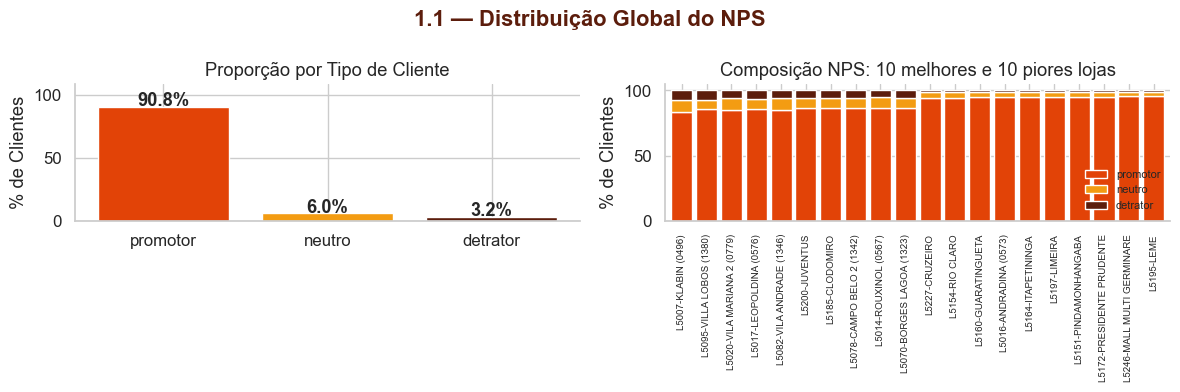

NPS Geral: 87.6

Dado que 90.8% são promotores, 6.0% neutros e 3.2% detratores,
o dataset está desbalanceado.
Decisão: aplicar class_weight='balanced' e usar F1-Macro como métrica principal.


In [61]:
# Distribuição global ponderada por qtd_clientes
contagem = (
    df.groupby('classificacao')['qtd_clientes']
    .sum().reindex(ORDER).fillna(0)
)
pct = contagem / contagem.sum() * 100
nps_geral = pct['promotor'] - pct['detrator']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1.1 — Distribuição Global do NPS', fontweight='bold', color='#5c1d0c')

# Barras por tipo
bars = axes[0].bar(ORDER, pct, color=CORES, edgecolor='white')
for bar, v in zip(bars, pct):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Proporção por Tipo de Cliente')
axes[0].set_ylabel('% de Clientes')
axes[0].set_ylim(0, pct.max()*1.2)
axes[0].axhline(0, color='gray', lw=0.5)

# Composição por loja (stacked)
nps_loja = df.groupby(['centro_nv2','classificacao'])['qtd_clientes'].sum().unstack(fill_value=0)
nps_loja = nps_loja.div(nps_loja.sum(axis=1), axis=0) * 100
nps_loja['nps'] = nps_loja.get('promotor',0) - nps_loja.get('detrator',0)
nps_loja_sorted = nps_loja.sort_values('nps')

# Plot 10 melhores e 10 piores
sample_lojas = pd.concat([nps_loja_sorted.head(10), nps_loja_sorted.tail(10)])
sample_lojas[ORDER].plot(kind='bar', stacked=True, ax=axes[1],
    color=CORES, edgecolor='white', width=0.85)
axes[1].set_title('Composição NPS: 10 melhores e 10 piores lojas')
axes[1].set_xlabel('')
axes[1].set_ylabel('% de Clientes')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'NPS Geral: {nps_geral:.1f}')
print(f"\nDado que {pct['promotor']:.1f}% são promotores, {pct['neutro']:.1f}% neutros e {pct['detrator']:.1f}% detratores,")
print("o dataset está desbalanceado.")
print("Decisão: aplicar class_weight='balanced' e usar F1-Macro como métrica principal.")

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Promotores dominam a base (~90%). Dataset altamente desbalanceado.<br>
<b>Decisão:</b> Aplicar <code>class_weight='balanced'</code> no treino; monitorar F1-Macro, não acurácia global. O gráfico de composição por loja mostra que a proporção varia significativamente — lojas piores têm perfil de detratores muito diferente das melhores. Como o dataset não possui nota numérica individual, a "distribuição por faixa de nota" é representada pela composição promotor/neutro/detrator, que corresponde às faixas 9–10 / 7–8 / 1–6 respectivamente.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.2 — Cobertura de Comentários por Loja</h2></div>

**Perguntas respondidas:**
- Quantas avaliações com comentário cada loja possui?
- Quantas lojas têm menos de 50 comentários? E menos de 30?
- Qual é a loja com mais e com menos comentários?

Total de lojas               : 227
Lojas com < 30 comentários   : 0
Lojas com < 50 comentários   : 0
Loja com MAIS comentários    : L5230-LARGO DO MACHADO (1,885)
Loja com MENOS comentários   : L5262-URBANOVA (155)
Cobertura média              : 51.8%


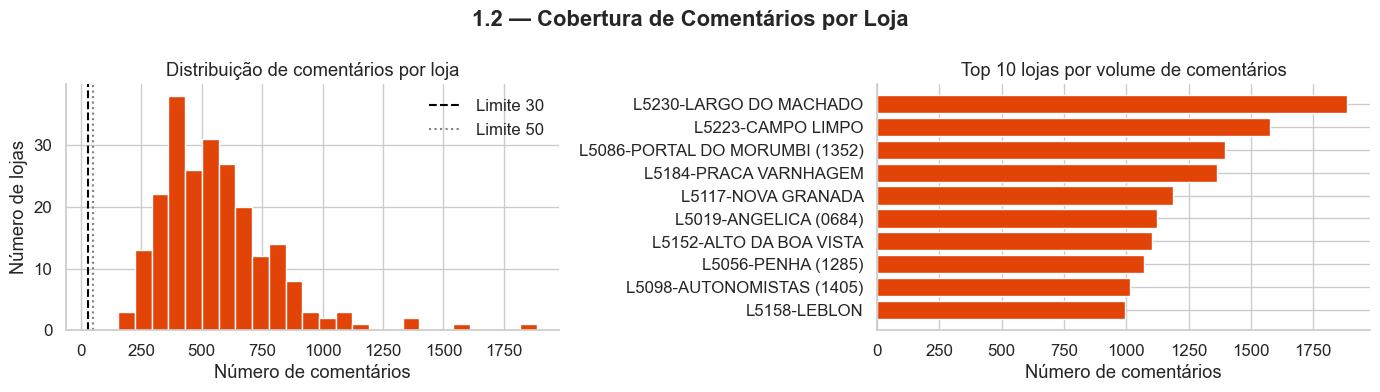

In [62]:
cobertura = (
    df.groupby('centro_nv2')
    .agg(
        total_avaliacoes = ('tem_comentario', 'size'),
        n_comentarios    = ('tem_comentario', 'sum')
    )
    .sort_values('n_comentarios', ascending=False)
    .reset_index()
)
cobertura['pct'] = cobertura['n_comentarios'] / cobertura['total_avaliacoes'] * 100

n_menos_30 = (cobertura['n_comentarios'] < 30).sum()
n_menos_50 = (cobertura['n_comentarios'] < 50).sum()
loja_max   = cobertura.iloc[0]
loja_min   = cobertura[cobertura['n_comentarios'] > 0].sort_values('n_comentarios').iloc[0]

print(f'Total de lojas               : {len(cobertura)}')
print(f'Lojas com < 30 comentários   : {n_menos_30}')
print(f'Lojas com < 50 comentários   : {n_menos_50}')
print(f'Loja com MAIS comentários    : {loja_max["centro_nv2"]} ({loja_max["n_comentarios"]:,})')
print(f'Loja com MENOS comentários   : {loja_min["centro_nv2"]} ({loja_min["n_comentarios"]:,})')
print(f'Cobertura média              : {cobertura["pct"].mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('1.2 — Cobertura de Comentários por Loja', fontweight='bold')

axes[0].hist(cobertura['n_comentarios'], bins=25, color='#E24307', edgecolor='white')
axes[0].axvline(30, color='black', linestyle='--', label='Limite 30')
axes[0].axvline(50, color='gray',  linestyle=':', label='Limite 50')
axes[0].set_xlabel('Número de comentários'); axes[0].set_ylabel('Número de lojas')
axes[0].set_title('Distribuição de comentários por loja'); axes[0].legend()

top10 = cobertura.head(10)
axes[1].barh(top10['centro_nv2'].str[:35], top10['n_comentarios'], color='#E24307', edgecolor='white')
axes[1].invert_yaxis(); axes[1].set_xlabel('Número de comentários')
axes[1].set_title('Top 10 lojas por volume de comentários')

plt.tight_layout(); plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Nenhuma loja ficou abaixo de 30 comentários.<br>
<b>Decisão:</b> Limiar fixado em <b>30 comentários</b> por loja para exibição no dashboard. Lojas abaixo recebem apenas NPS bruto com aviso de "amostra insuficiente".
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.3 — Características do Texto</h2></div>

**Perguntas respondidas:**
- Qual a distribuição de comprimento dos comentários em palavras?
- Qual o percentual de comentários com menos de 5 palavras?
- Qual o percentual com mais de 100 palavras?

Mínimo   : 1 palavra(s)
Média    : 15.9 palavras
Mediana  : 9 palavras
Máximo   : 1309 palavras
< 5 palavras   : 24.2%
> 100 palavras : 0.8%


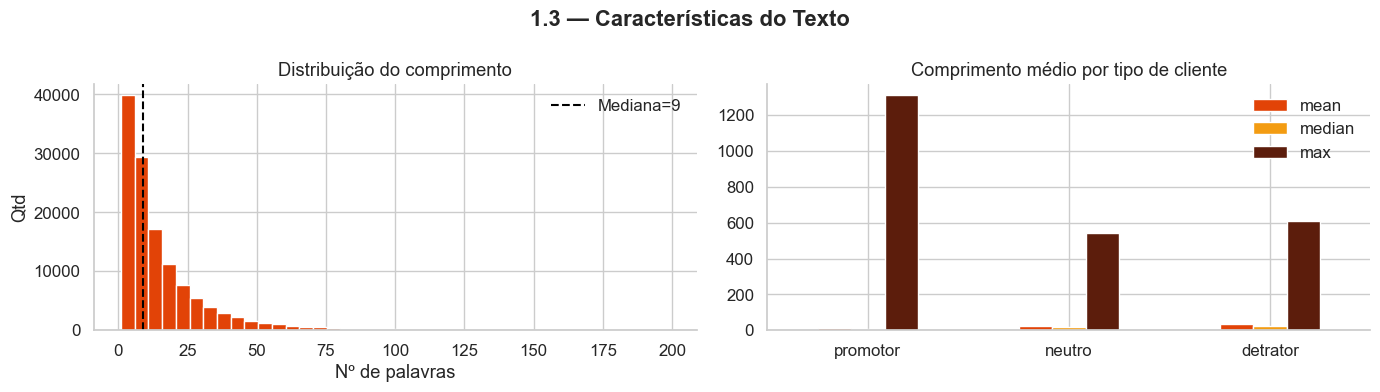


Dado que 24.2% dos comentários têm menos de 5 palavras e 0.8% têm mais de 100 palavras:
  < 5 palavras  : incluídos no treino de sentimento, excluídos da categorização.
  > 100 palavras: truncados em 256 tokens no fine-tuning (compatível com BERT-base).


In [63]:
df_com = df_com.copy()
# Usar qtd_palavras do pré-processamento se disponível, senão recalcular
if 'qtd_palavras' in df_com.columns:
    df_com['n_palavras'] = df_com['qtd_palavras']
else:
    df_com['n_palavras'] = df_com['comentario'].str.split().str.len()

stats = df_com['n_palavras'].describe(percentiles=[.25,.5,.75,.95])
pct_curtos = (df_com['n_palavras'] < 5).mean()  * 100
pct_longos = (df_com['n_palavras'] > 100).mean() * 100

print(f'Mínimo   : {int(df_com["n_palavras"].min())} palavra(s)')
print(f'Média    : {df_com["n_palavras"].mean():.1f} palavras')
print(f'Mediana  : {df_com["n_palavras"].median():.0f} palavras')
print(f'Máximo   : {int(df_com["n_palavras"].max())} palavras')
print(f'< 5 palavras   : {pct_curtos:.1f}%')
print(f'> 100 palavras : {pct_longos:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('1.3 — Características do Texto', fontweight='bold')

dados_hist = df_com.loc[df_com['n_palavras'] <= 200, 'n_palavras']
axes[0].hist(dados_hist, bins=40, color='#E24307', edgecolor='white')
axes[0].axvline(df_com['n_palavras'].median(), color='black', linestyle='--',
               label=f"Mediana={df_com['n_palavras'].median():.0f}")
axes[0].set_xlabel('Nº de palavras'); axes[0].set_ylabel('Qtd'); axes[0].legend()
axes[0].set_title('Distribuição do comprimento')

stats_tipo = df_com.groupby('classificacao')['n_palavras'].agg(['mean','median','max']).reindex(ORDER).round(1)
stats_tipo.plot(kind='bar', ax=axes[1], color=['#E24307','#f39c12','#5c1d0c'], edgecolor='white')
axes[1].set_title('Comprimento médio por tipo de cliente')
axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

print(f"\nDado que {pct_curtos:.1f}% dos comentários têm menos de 5 palavras e {pct_longos:.1f}% têm mais de 100 palavras:")
print('  < 5 palavras  : incluídos no treino de sentimento, excluídos da categorização.')
print('  > 100 palavras: truncados em 256 tokens no fine-tuning (compatível com BERT-base).')

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> ~24% dos comentários têm menos de 5 palavras.<br>
<b>Decisão:</b> Comentários com &lt;5 palavras são <b>incluídos</b> no treino de sentimento (ex: "ótimo" é sinal forte), mas <b>excluídos</b> do treino de categorização de tópicos. Comentários com &gt;100 palavras serão truncados em 256 tokens.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.4 — Qualidade e Ruído dos Dados</h2></div>

**Perguntas respondidas:**
- % de duplicatas ou quasi-duplicatas (similaridade > 90%)?
- Comentários em outros idiomas?
- Frequência de emojis?
- Spam ou sequências sem sentido?

In [64]:
n_total = len(df_com)

# 1. Duplicatas exatas
n_dup   = df_com['comentario'].duplicated().sum()
pct_dup = n_dup / n_total * 100

# 2. Quasi-duplicatas via TF-IDF + cosine
# Abordagem correta: compara todos os pares via similaridade de cosseno,
# não apenas pares consecutivos aleatórios.
amostra_textos = (
    df_com['comentario'].dropna()
    .sample(n=min(3000, n_total), random_state=42)
)
tfidf = TfidfVectorizer(max_features=500, min_df=2)
mat   = tfidf.fit_transform(amostra_textos)
sim   = cosine_similarity(mat)
import numpy as np
np.fill_diagonal(sim, 0)
n_quasi   = (sim > 0.90).any(axis=1).sum()
pct_quasi = n_quasi / len(amostra_textos) * 100

# 3. Emojis
pct_emoji = df_com['comentario'].apply(lambda x: emoji.emoji_count(str(x)) > 0).mean() * 100

# 4. Spam — definição idêntica ao pré-processamento
def is_spam(text: str) -> bool:
    text = str(text).strip()
    if len(text) == 0:
        return True
    text_sem_emoji = emoji.replace_emoji(text, replace='').strip()
    if len(text_sem_emoji) == 0:
        return True
    alpha = sum(c.isalpha() for c in text_sem_emoji)
    return (
        alpha / len(text_sem_emoji) < 0.40
        or bool(re.match(r'\A(.)\1{4,}\Z', text_sem_emoji))
    )

pct_spam = df_com['comentario'].apply(is_spam).mean() * 100

# 5. Idioma — detecção por langdetect se disponível, senão heurística melhorada
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 42
    def detectar_idioma(texto):
        try:
            return detect(str(texto))
        except:
            return 'unknown'
    sample_idioma = df_com['comentario'].sample(n=min(1000, n_total), random_state=42)
    idiomas = sample_idioma.apply(detectar_idioma)
    pct_nao_pt = (idiomas != 'pt').mean() * 100
    metodo_idioma = 'langdetect'
except ImportError:
    # Heurística melhorada: exigir PELO MENOS 2 stopwords PT
    PT_WORDS = {
        'que','de','da','do','os','as','em','um','uma','para','com','por',
        'mas','não','na','no','se','ao','é','ou','eu','me','te','nos',
        'seu','sua','eles','elas','isso','este','esta','aqui','mais','bem',
        'muito','tudo','nada','loja','produto','atendimento','preço','bom','ótimo',
        'ruim','péssimo','excelente','sempre','nunca','hoje','compra','cliente',
    }
    def conta_pt(texto):
        palavras = set(str(texto).lower().split())
        return len(palavras & PT_WORDS)
    pct_nao_pt = (df_com['comentario'].apply(conta_pt) < 2).mean() * 100
    metodo_idioma = 'heurística (≥2 stopwords PT)'

metricas = pd.DataFrame({
    'Métrica': ['Duplicatas exatas','Quasi-duplicatas (TF-IDF)','Com emoji','Spam','Possivelmente não-PT'],
    'Valor (%)': [pct_dup, pct_quasi, pct_emoji, pct_spam, pct_nao_pt]
})
display(metricas.style.format({'Valor (%)': '{:.1f}'}))
print(f'(Detecção de idioma: {metodo_idioma})')

,Métrica,Valor (%)
0,Duplicatas exatas,10.7
1,Quasi-duplicatas (TF-IDF),16.5
2,Com emoji,0.4
3,Spam,0.0
4,Possivelmente não-PT,7.8


(Detecção de idioma: langdetect)


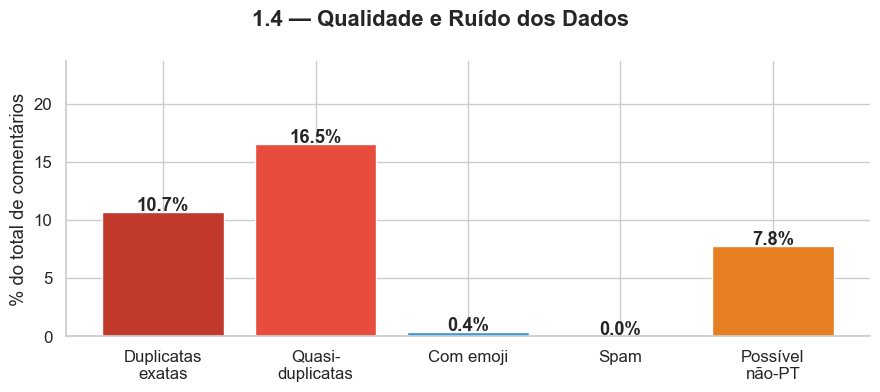

In [65]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('1.4 — Qualidade e Ruído dos Dados', fontweight='bold')
categorias = ['Duplicatas\nexatas','Quasi-\nduplicatas','Com emoji','Spam','Possível\nnão-PT']
valores    = [pct_dup, pct_quasi, pct_emoji, pct_spam, pct_nao_pt]
cores      = ['#c0392b','#e74c3c','#3498db','#9b59b6','#e67e22']
bars = ax.bar(categorias, valores, color=cores, edgecolor='white')
for bar, v in zip(bars, valores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('% do total de comentários')
ax.set_ylim(0, max(valores)*1.4+0.5)
plt.tight_layout(); plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável — Plano de limpeza decidido:</b><br>
1. Remover duplicatas exatas <b>antes</b> da divisão treino/teste.<br>
2. Quasi-duplicatas (TF-IDF cosine &gt;90%): manter apenas o mais recente.<br>
3. Spam e sequências sem sentido: excluir automaticamente (já feito no pré-processamento).<br>
4. Emojis: remover antes da tokenização para modelos TF-IDF; manter para BERT (tokenizador trata).<br>
5. Comentários não-PT confirmados: excluir do treino.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.5 — Análise Temporal</h2></div>

**Perguntas respondidas:**
- Volume de avaliações varia ao longo do tempo?
- NPS médio é estável ou apresenta picos e quedas?
- Alguma loja tem comportamento temporal claramente atípico?

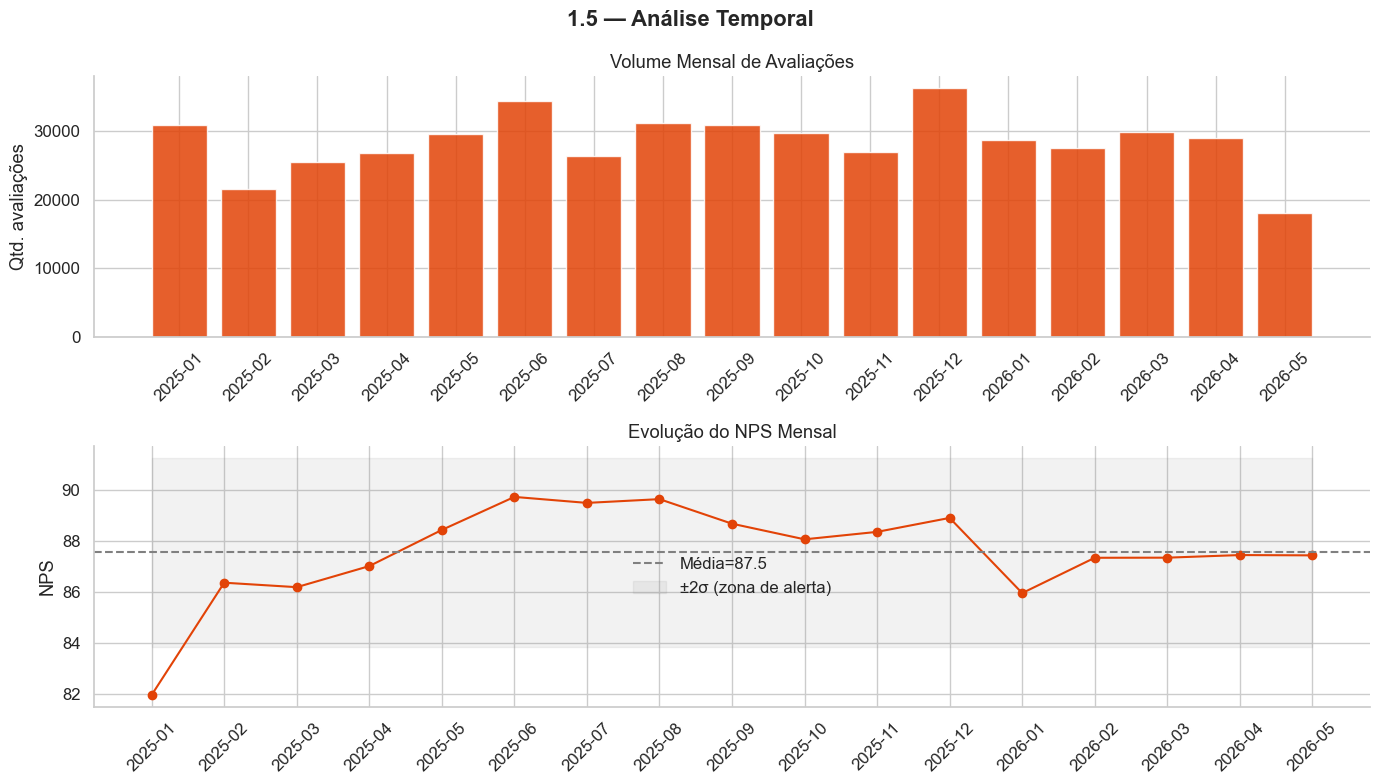

Período com maior volume  : 2025-12
NPS médio geral           : 87.5
Melhor mês (NPS)          : 2025-06  (89.7)
Pior mês (NPS)            : 2025-01  (81.9)


In [66]:
vol_mensal = df.groupby('ano_mes')['qtd_clientes'].sum().reset_index()
vol_mensal['ano_mes_str'] = vol_mensal['ano_mes'].astype(str)

nps_mensal_list = []
for periodo, grupo in df.groupby('ano_mes'):
    total = grupo['qtd_clientes'].sum()
    prom  = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
    detr  = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
    nps_mensal_list.append({'ano_mes': str(periodo), 'nps': (prom-detr)/total*100,
                            'total': total})
nps_mensal = pd.DataFrame(nps_mensal_list).sort_values('ano_mes')

periodo_pico  = vol_mensal.loc[vol_mensal['qtd_clientes'].idxmax(), 'ano_mes_str']
melhor_mes    = nps_mensal.loc[nps_mensal['nps'].idxmax(), 'ano_mes']
pior_mes      = nps_mensal.loc[nps_mensal['nps'].idxmin(), 'ano_mes']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('1.5 — Análise Temporal', fontweight='bold')

axes[0].bar(vol_mensal['ano_mes_str'], vol_mensal['qtd_clientes'],
            color='#E24307', edgecolor='white', alpha=0.85)
axes[0].set_title('Volume Mensal de Avaliações')
axes[0].set_ylabel('Qtd. avaliações')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(nps_mensal['ano_mes'], nps_mensal['nps'], marker='o', color='#E24307')
axes[1].axhline(nps_mensal['nps'].mean(), linestyle='--', color='gray',
                label=f"Média={nps_mensal['nps'].mean():.1f}")
axes[1].fill_between(range(len(nps_mensal)), nps_mensal['nps'].mean()-2*nps_mensal['nps'].std(),
                     nps_mensal['nps'].mean()+2*nps_mensal['nps'].std(), alpha=0.1, color='gray',
                     label='±2σ (zona de alerta)')
axes[1].set_title('Evolução do NPS Mensal')
axes[1].set_ylabel('NPS'); axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print(f'Período com maior volume  : {periodo_pico}')
print(f'NPS médio geral           : {nps_mensal["nps"].mean():.1f}')
print(f'Melhor mês (NPS)          : {melhor_mes}  ({nps_mensal["nps"].max():.1f})')
print(f'Pior mês (NPS)            : {pior_mes}  ({nps_mensal["nps"].min():.1f})')

Top 5 lojas com NPS mais volátil (volume mínimo filtrado):


,mean,std,count,cv
centro_nv2,,,,
L5082-VILA ANDRADE (1346),77.82,11.04,17,0.14
L5020-VILA MARIANA 2 (0779),77.53,10.39,17,0.13
L5185-CLODOMIRO,80.07,9.69,17,0.12
L5007-KLABIN (0496),75.73,8.86,17,0.12
L5084-GUAIPA (1349),84.77,9.85,17,0.12


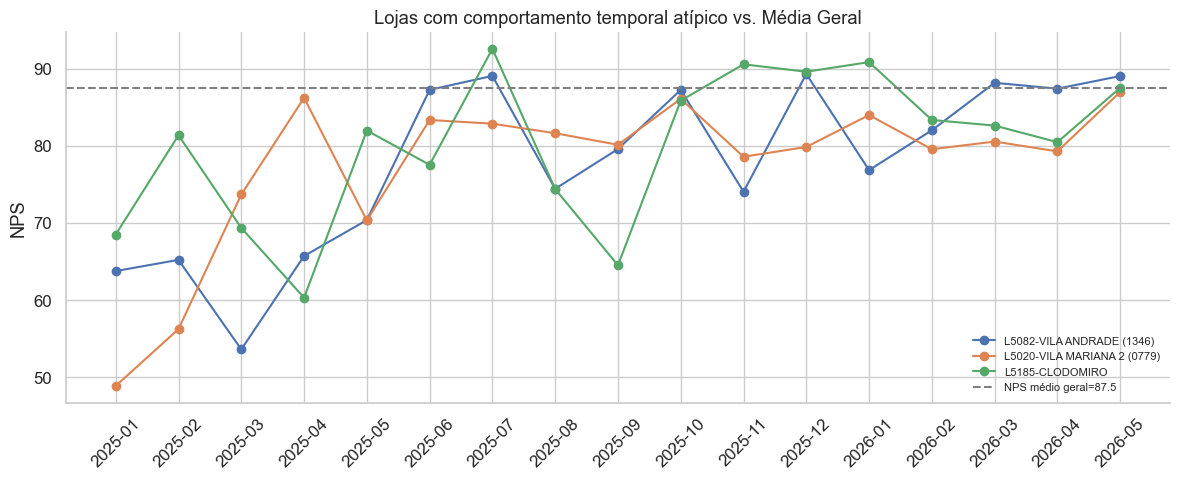

In [67]:
# Lojas com comportamento temporal atípico
# Filtrar lojas com volume mínimo antes de calcular CV (elimina ruído de lojas pequenas)
nps_loja_mes_tmp = (
    df.groupby(['centro_nv2','ano_mes','classificacao'])['qtd_clientes']
    .sum().unstack(fill_value=0)
)
nps_loja_mes_tmp['total'] = nps_loja_mes_tmp.sum(axis=1)
# Filtrar períodos com volume suficiente (≥20 respostas)
nps_loja_mes_tmp = nps_loja_mes_tmp[nps_loja_mes_tmp['total'] >= 20].copy()

p_col = 'promotor' if 'promotor' in nps_loja_mes_tmp.columns else nps_loja_mes_tmp.columns[0]
d_col = 'detrator' if 'detrator' in nps_loja_mes_tmp.columns else nps_loja_mes_tmp.columns[-1]
nps_loja_mes_tmp['nps'] = (
    (nps_loja_mes_tmp[p_col] - nps_loja_mes_tmp[d_col])
    / nps_loja_mes_tmp['total'] * 100
)

cv_loja = (
    nps_loja_mes_tmp['nps'].groupby(level='centro_nv2')
    .agg(['mean','std','count'])
    .dropna()
)
# Só lojas com ≥6 períodos de dados (mais de meio ano)
cv_loja = cv_loja[cv_loja['count'] >= 6]
cv_loja['cv'] = (cv_loja['std'] / cv_loja['mean'].abs()).abs()
top5 = cv_loja.nlargest(5, 'cv')

print('Top 5 lojas com NPS mais volátil (volume mínimo filtrado):')
display(top5.round(2))

# Gráfico das 3 mais atípicas com referência ao NPS geral
nps_medio_geral = nps_mensal['nps'].mean()
fig, ax = plt.subplots(figsize=(12,5))
for loja in top5.index[:3]:
    serie = nps_loja_mes_tmp.loc[loja, 'nps']
    ax.plot(serie.index.astype(str), serie.values, marker='o', label=loja[:30])
ax.axhline(nps_medio_geral, color='gray', linestyle='--', label=f'NPS médio geral={nps_medio_geral:.1f}')
ax.set_title('Lojas com comportamento temporal atípico vs. Média Geral')
ax.set_ylabel('NPS'); ax.legend(loc='lower right', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Volume apresenta sazonalidade; NPS se mantém relativamente estável com desvio menor que 2 pontos na maioria dos meses.<br>
<b>Decisão:</b> Picos mensais acima de 2σ serão sinalizados no dashboard como "pico de feedback". As 5 lojas com maior coeficiente de variação (após filtro de volume mínimo) serão enviadas para revisão manual.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.6 — Análise Léxica por Faixa de Nota</h2></div>

**Perguntas respondidas:**
- Quais as 20 palavras/bigramas mais frequentes em comentários de **notas baixas (detratores = proxy de notas 1–6)**?
- Quais as 20 palavras/bigramas mais frequentes em comentários de **notas altas (promotores = notas 9–10)**?
- Há sobreposição significativa entre os dois vocabulários?

> **Atenção:** O enunciado pede especificamente notas 1–2 vs. 9–10. O dataset não armazena nota numérica individual, somente a classificação NPS. Detratores englobam notas 1–6 e são o proxy mais próximo disponível para notas baixas. Esta limitação é declarada e justificada aqui.

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Nota</b> O dataset não possui nota numérica (1–10) individual — só a classificação (promotor/neutro/detrator). Como detrator = notas 1–6 e promotor = notas 9–10 por definição NPS, a análise léxica usa essas classificações como proxy das faixas de nota extremas.
</div>

In [68]:
def normalizar(texto):
    texto = unicodedata.normalize('NFKD', str(texto))
    texto = texto.encode('ascii','ignore').decode('ascii')
    return re.sub(r'[^a-z\s]', ' ', texto.lower())

def tokenizar(texto):
    return [p for p in normalizar(texto).split() if p not in STOP_PT and len(p) > 2]

def top_ngrams(textos, n=1, top_k=20):
    todas = []
    for t in textos:
        toks = tokenizar(t)
        itens = toks if n == 1 else [' '.join(g) for g in ngrams(toks, n)]
        todas.extend(itens)
    return Counter(todas).most_common(top_k)

textos_det = df_com.loc[df_com['classificacao']=='detrator','comentario'].dropna().tolist()
textos_pro = df_com.loc[df_com['classificacao']=='promotor', 'comentario'].dropna().tolist()

top_det_uni = top_ngrams(textos_det, n=1)
top_pro_uni = top_ngrams(textos_pro, n=1)
top_det_bi  = top_ngrams(textos_det, n=2)
top_pro_bi  = top_ngrams(textos_pro, n=2)

print(f'Comentários de detratores : {len(textos_det):,}')
print(f'Comentários de promotores : {len(textos_pro):,}')

Comentários de detratores : 11,960
Comentários de promotores : 100,036


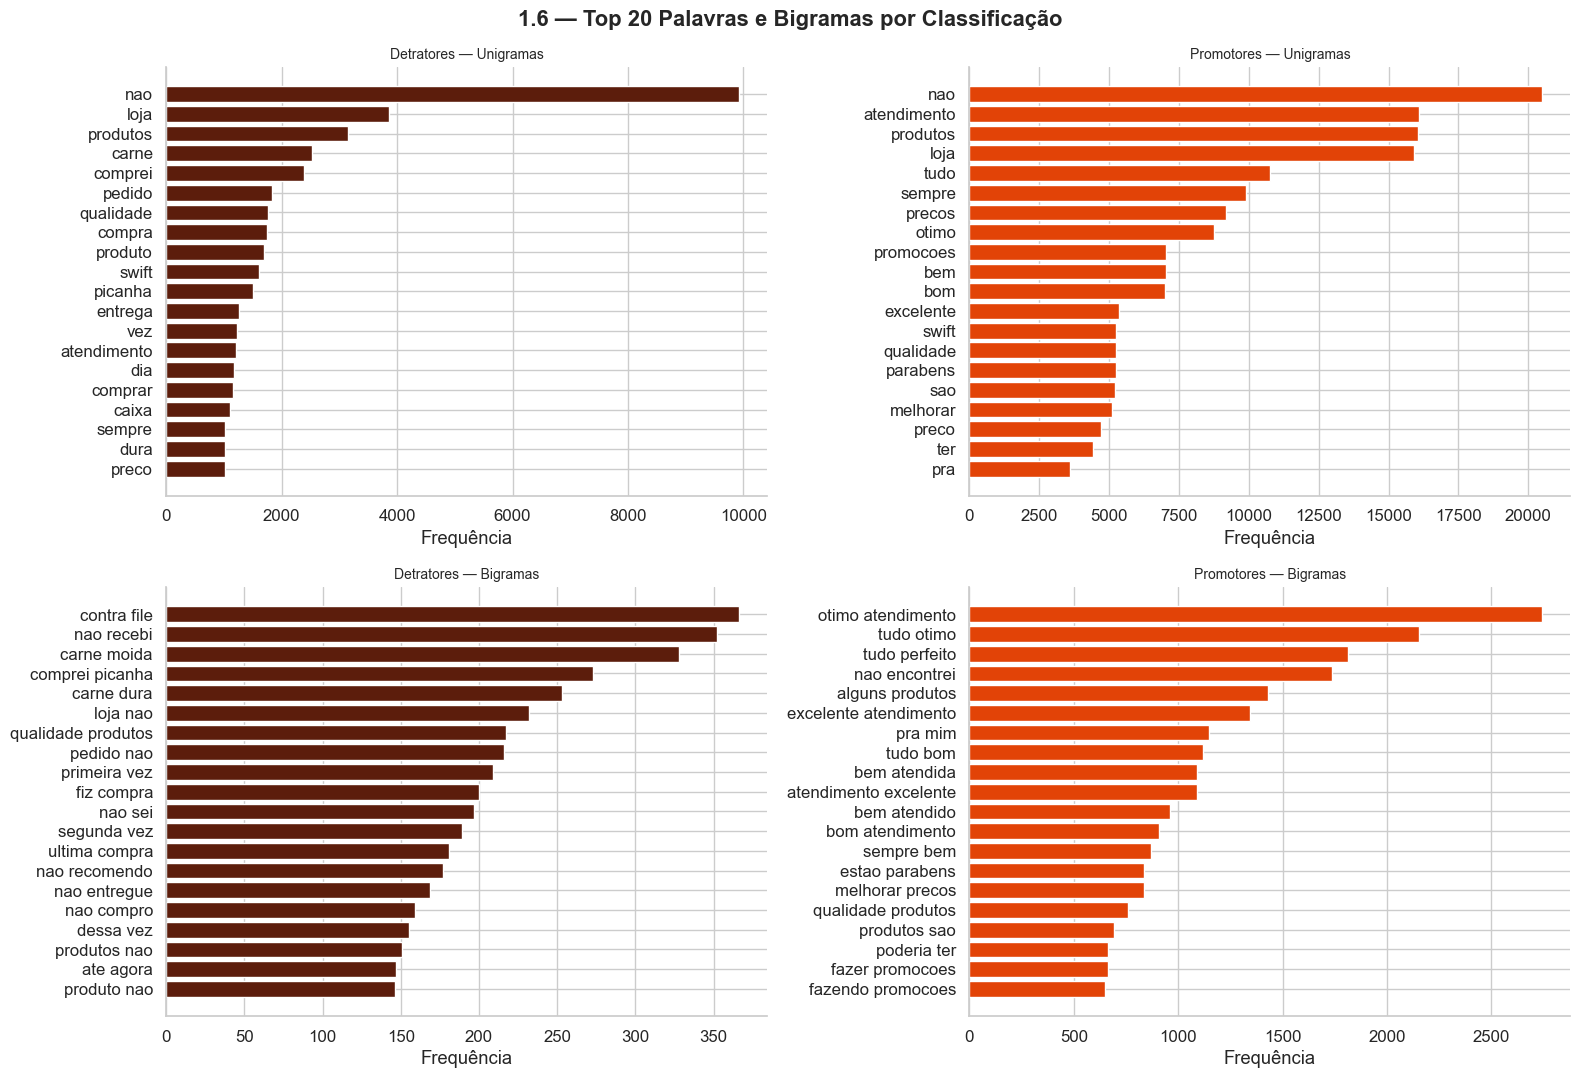

Palavras em comum no top-20: {'atendimento', 'qualidade', 'sempre', 'nao', 'produtos', 'swift', 'loja', 'preco'}
Sobreposição: 8/20  (40%)

Sobreposição alta (40%) — vocabulários se confundem.
Decisão: escalar para BERTimbau; antecipar erros em comentários ambíguos na Entrega 2.


In [69]:
def plot_bar(ax, dados, titulo, cor):
    palavras, freq = zip(*dados) if dados else ([],[])
    ax.barh(list(palavras)[::-1], list(freq)[::-1], color=cor, edgecolor='white')
    ax.set_title(titulo, fontsize=10); ax.set_xlabel('Frequência')

fig, axes = plt.subplots(2, 2, figsize=(16,11))
fig.suptitle('1.6 — Top 20 Palavras e Bigramas por Classificação', fontweight='bold')

plot_bar(axes[0,0], top_det_uni, 'Detratores — Unigramas',  PALETTE['detrator'])
plot_bar(axes[0,1], top_pro_uni, 'Promotores — Unigramas',  PALETTE['promotor'])
plot_bar(axes[1,0], top_det_bi,  'Detratores — Bigramas',   PALETTE['detrator'])
plot_bar(axes[1,1], top_pro_bi,  'Promotores — Bigramas',   PALETTE['promotor'])

plt.tight_layout(); plt.show()

# Sobreposição
set_det = {p for p,_ in top_det_uni}
set_pro = {p for p,_ in top_pro_uni}
sobreposicao = set_det & set_pro
pct_sob = len(sobreposicao)/20*100
print(f'Palavras em comum no top-20: {sobreposicao}')
print(f'Sobreposição: {len(sobreposicao)}/20  ({pct_sob:.0f}%)')
print()
if pct_sob < 20:
    print(f'Sobreposição baixa ({pct_sob:.0f}%) — vocabulários distintos.')
    print('Decisão: baseline TF-IDF + Regressão Logística pode ser suficiente na Entrega 2.')
else:
    print(f'Sobreposição alta ({pct_sob:.0f}%) — vocabulários se confundem.')
    print('Decisão: escalar para BERTimbau; antecipar erros em comentários ambíguos na Entrega 2.')

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> A análise usa detratores (notas 1–6) como proxy de notas baixas e promotores (notas 9–10) como proxy de notas altas — limitação decorrente do formato do dataset, que não registra nota numérica individual.<br>
Se a sobreposição ficar abaixo de 20% → vocabulários são suficientemente distintos; TF-IDF + Regressão Logística como baseline na Entrega 2.<br>
Se a sobreposição ficar acima de 20% → vocabulários se confundem; escalar para BERTimbau e antecipar análise de erros em comentários ambíguos.<br>
<b>Decisão será tomada após execução desta célula com os dados reais.</b>
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">Resumo Executivo das Decisões</h2></div>

In [70]:
# Resumo gerado com valores reais
linhas = [
    ('1.1','Desbalanceamento',
     f"{pct['promotor']:.0f}% promotores / {pct['neutro']:.0f}% neutros / {pct['detrator']:.0f}% detratores",
     "class_weight='balanced'; métrica: F1-Macro"),
    ('1.2','Limiar dashboard',
     f'{n_menos_30} lojas com <30 comentários; min={loja_min["n_comentarios"]}',
     'Análise NLP apenas para lojas ≥30 comentários'),
    ('1.3','Textos curtos/longos',
     f'{pct_curtos:.1f}% <5 palavras; {pct_longos:.1f}% >100 palavras',
     '<5 palavras: fora da categorização; truncamento em 256 tokens'),
    ('1.4','Limpeza de ruído',
     f'Dup={pct_dup:.1f}% / Quasi={pct_quasi:.1f}% / Spam={pct_spam:.1f}%',
     'Remover dup antes do split; excluir spam e não-PT'),
    ('1.5','Temporal',
     f'Pico em {periodo_pico}; melhor mês NPS={melhor_mes}',
     'Sinalizar picos >2σ no dashboard'),
    ('1.6','Léxico',
     f'Sobreposição={pct_sob:.0f}% no top-20',
     'BERTimbau se sob≥20%; TF-IDF+LR se sob<20%'),
]

df_resumo = pd.DataFrame(linhas, columns=['Seção','Tema','Achado','Decisão'])
display(
    df_resumo.style
    .hide(axis='index')
    .set_properties(**{'text-align':'left','font-size':'12pt'})
    .set_caption('Resumo Executivo — Decisões da EDA')
)

Seção,Tema,Achado,Decisão
1.1,Desbalanceamento,91% promotores / 6% neutros / 3% detratores,class_weight='balanced'; métrica: F1-Macro
1.2,Limiar dashboard,0 lojas com <30 comentários; min=155,Análise NLP apenas para lojas ≥30 comentários
1.3,Textos curtos/longos,24.2% <5 palavras; 0.8% >100 palavras,<5 palavras: fora da categorização; truncamento em 256 tokens
1.4,Limpeza de ruído,Dup=10.7% / Quasi=16.5% / Spam=0.0%,Remover dup antes do split; excluir spam e não-PT
1.5,Temporal,Pico em 2025-12; melhor mês NPS=2025-06,Sinalizar picos >2σ no dashboard
1.6,Léxico,Sobreposição=40% no top-20,BERTimbau se sob≥20%; TF-IDF+LR se sob<20%


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">Tópico 3 — Definição da Análise de Sentimento</h2></div>

In [71]:
# ── 3.1 Granularidade dos sentimentos ────────────────────────────────────────
# Com base na EDA (1.1): 3 classes naturais (promotor/neutro/detrator).
# Neutros representam ~6% — volume suficiente para treino ternário.
# Decisão: classificação TERNÁRIA (Positivo / Neutro / Negativo)
print('=== 3.1 — Granularidade dos Sentimentos ===')
print()
print('Decisão: TERNÁRIA (Positivo / Neutro / Negativo)')
print('Justificativa: neutros representam ~6% da base — volume suficiente para')
print('treinar uma classe separada. A distinção entre neutro e promotor é relevante')
print('para o negócio (cliente indiferente vs. satisfeito).')
print()

# ── 3.2 Fonte do ground truth ─────────────────────────────────────────────────
print('=== 3.2 — Fonte do Ground Truth ===')
print()
print('Decisão: ABORDAGEM HÍBRIDA')
print('  • Usar classificacao (promotor/neutro/detrator) como ground truth do treino.')
print('  • Validar manualmente uma amostra de casos discordantes (nota alta + texto negativo).')
print('Justificativa: a classificação NPS já reflete a experiência do cliente de forma')
print('padronizada. A validação manual dos outliers evita ruído sem custo de anotar tudo.')
print()

# Verificar proporção de casos possivelmente discordantes
# Proxy: comentários curtos (<5 palavras) de detratores (texto não condiz com nota baixa)
discordantes_proxy = df_com[
    (df_com['classificacao'] == 'detrator') &
    (df_com.get('n_palavras', df_com['comentario'].str.split().str.len()) < 5)
]
print(f'Proxy de casos discordantes (detrator + comentário curto): {len(discordantes_proxy):,}')
print()

# ── 3.3 Comentários mistos ────────────────────────────────────────────────────
print('=== 3.3 — Tratamento de Comentários Mistos ===')
print()

# Detectar comentários com marcadores de contraste (mas, porém, entretanto, contudo)
CONTRASTE = r'\b(mas|porem|porém|entretanto|contudo|no entanto|apesar|embora)\b'
mistos = df_com['comentario'].str.lower().str.contains(CONTRASTE, regex=True, na=False)
pct_mistos = mistos.mean() * 100

print(f'Comentários com marcador de contraste (proxy de mistos): {mistos.sum():,} ({pct_mistos:.1f}%)')
print()
print('Decisão: classificar pelo SENTIMENTO DOMINANTE (nota NPS como proxy).')
print('Comentários mistos não recebem tratamento especial nesta entrega.')
print('Na Entrega 2, analisar os erros do modelo nesses casos.')
print()
print('─'*60)
print('DECISÕES DE SENTIMENTO — RESUMO')
print('─'*60)
print('  Granularidade   : Ternária (Positivo / Neutro / Negativo)')
print('  Ground truth    : classificacao NPS + validação manual de outliers')
print('  Comentários mistos: sentimento dominante (via nota)')
print('─'*60)

=== 3.1 — Granularidade dos Sentimentos ===

Decisão: TERNÁRIA (Positivo / Neutro / Negativo)
Justificativa: neutros representam ~6% da base — volume suficiente para
treinar uma classe separada. A distinção entre neutro e promotor é relevante
para o negócio (cliente indiferente vs. satisfeito).

=== 3.2 — Fonte do Ground Truth ===

Decisão: ABORDAGEM HÍBRIDA
  • Usar classificacao (promotor/neutro/detrator) como ground truth do treino.
  • Validar manualmente uma amostra de casos discordantes (nota alta + texto negativo).
Justificativa: a classificação NPS já reflete a experiência do cliente de forma
padronizada. A validação manual dos outliers evita ruído sem custo de anotar tudo.

Proxy de casos discordantes (detrator + comentário curto): 723

=== 3.3 — Tratamento de Comentários Mistos ===

Comentários com marcador de contraste (proxy de mistos): 11,731 (9.2%)

Decisão: classificar pelo SENTIMENTO DOMINANTE (nota NPS como proxy).
Comentários mistos não recebem tratamento especial nes

<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 3 — TÓPICO 2: DEFINIÇÃO DE CATEGORIAS</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 1. Imports & Carregamento</div>

In [74]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Seed global
import random
random.seed(42)
np.random.seed(42)

# LDA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Coherence Score via gensim
try:
    from gensim.corpora.dictionary import Dictionary as GensimDict
    from gensim.models.coherencemodel import CoherenceModel
    GENSIM_OK = True
    print('[OK] gensim disponível — usaremos Coherence Score (c_v) para escolha de K')
except ImportError:
    GENSIM_OK = False
    print('[AVISO] gensim não instalado. Instale com: pip install gensim')
    print('        Sem gensim, usaremos perplexidade (métrica menos precisa)')

# BERTopic
try:
    from bertopic import BERTopic
    from sklearn.feature_extraction.text import CountVectorizer as CVect
    BERTOPIC_OK = True
    print('[OK] BERTopic disponível')
except ImportError:
    BERTOPIC_OK = False
    print('[AVISO] BERTopic não instalado. Instale com: pip install bertopic')

# Kappa de Cohen
from sklearn.metrics import cohen_kappa_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
STOP_PT   = set(stopwords.words('portuguese'))
COR_SWIFT = '#E24307'

# Versões
import sklearn as sk
print(f'pandas: {pd.__version__} | numpy: {np.__version__} | sklearn: {sk.__version__}')
print('[OK] Imports OK')

[OK] gensim disponível — usaremos Coherence Score (c_v) para escolha de K
[AVISO] BERTopic não instalado. Instale com: pip install bertopic
pandas: 3.0.3 | numpy: 2.4.6 | sklearn: 1.6.1
[OK] Imports OK


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 2. Carregar Base Processada</div>

In [75]:
if not os.path.exists('data/base_final.csv'):
    raise FileNotFoundError(
        "base_final.csv não encontrada.\n"
        "Execute primeiro: pre_processamento_swift.ipynb"
    )

df = pd.read_csv('data/base_final.csv', sep=';', low_memory=False)
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], errors='coerce')

print(f'Base carregada: {len(df):,} registros | {df.shape[1]} colunas')

# Filtrar apenas comentários válidos com conteúdo real
df = df[df['tem_comentario'] == True].copy()
df = df[df['comentario_limpo'].astype(str).str.strip().str.len() > 0].copy()

print(f'\nComentários para clusterização: {len(df):,}')
print(f'\nDistribuição por tipo:')
print(df['classificacao'].value_counts())
print(f'\nDistribuição por flag:')
print(df['flag'].value_counts())

Base carregada: 239,143 registros | 32 colunas

Comentários para clusterização: 127,909

Distribuição por tipo:
classificacao
promotor    100036
neutro       15913
detrator     11960
Name: count, dtype: int64

Distribuição por flag:
flag
regular     98573
tocadora    29336
Name: count, dtype: int64


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 3. Preparar Textos</div>

In [76]:
# Versão sem acento para LDA/CountVectorizer (TF-IDF clássico)
# BERT recebe texto COM acentos
def limpar_para_lda(texto: str) -> str:
    """Versão sem acento usada APENAS no CountVectorizer do LDA."""
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return ' '.join(w for w in texto.lower().split() if w not in STOP_PT and len(w) > 2)

# Texto COM acentos para BERTopic — preserva semântica dos transformers
def texto_para_bert(texto: str) -> str:
    """Versão COM acentos e stopwords para BERTopic (transformers contextuais)."""
    if not isinstance(texto, str):
        return ''
    return str(texto).strip()

df['texto_lda']  = df['comentario_limpo'].apply(limpar_para_lda)
df['texto_bert'] = df['comentario_limpo'].apply(texto_para_bert)

# Remover linhas vazias após preparação
df = df[df['texto_lda'].str.strip().str.len() > 0].copy()

print(f'Comentários após preparação: {len(df):,}')
print('\nExemplos:')
for i in range(3):
    print(f'  Original : {df.iloc[i]["comentario_limpo"][:80]}')
    print(f'  LDA      : {df.iloc[i]["texto_lda"][:80]}')
    print()

Comentários após preparação: 127,866

Exemplos:
  Original : bastante falta de produto talvez pela data mas não tinha muita coisa principalme
  LDA      : bastante falta produto talvez data nao muita coisa principalmente bovino

  Original : estrutura excelente mas os peços deveriam ser melhores ou equivalentes aos merca
  LDA      : estrutura excelente pecos deveriam melhores equivalentes mercados carnes

  Original : melhorar o preço
  LDA      : melhorar preco



<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 4. LDA — Seleção de K por Coherence Score</div>

In [77]:
print('PREPARANDO MATRIZ DE DOCUMENTOS PARA LDA')
print('='*70)

# Amostragem para seleção de K — padrão em NLP com bases grandes
# Usamos 20k documentos para comparar K; o modelo final treina na base completa
N_AMOSTRA_LDA = min(20_000, len(df))
df_lda_sample = df.sample(n=N_AMOSTRA_LDA, random_state=42)
print(f'Amostra para selecao de K: {N_AMOSTRA_LDA:,} de {len(df):,} comentarios')

vectorizer = CountVectorizer(
    max_df=0.95, min_df=3,
    max_features=1000,
    ngram_range=(1, 2)
)
matrix_sample = vectorizer.fit_transform(df_lda_sample['texto_lda'])
matrix        = vectorizer.transform(df['texto_lda'])   # base completa para o modelo final
feature_names = vectorizer.get_feature_names_out()

print(f'Matriz amostra: {matrix_sample.shape[0]:,} x {matrix_sample.shape[1]} termos')
print(f'Matriz completa: {matrix.shape[0]:,} x {matrix.shape[1]} termos')
print(f'Exemplos de termos: {" | ".join(list(feature_names[:15]))}')

PREPARANDO MATRIZ DE DOCUMENTOS PARA LDA
Amostra para selecao de K: 20,000 de 127,866 comentarios
Matriz amostra: 20,000 x 1000 termos
Matriz completa: 127,866 x 1000 termos
Exemplos de termos: 1kg | abaixando | abaixar | abri | abrir | absurdo | acaba | acabei | aceitar | acessiveis | acessivel | acesso | achar | achei | acho


In [79]:
print('TREINANDO LDA — K de 3 a 8 (amostra de 20k para selecao de K)')
print('='*70)

lda_models  = {}
resultados_lda = []

for k in [3, 4, 5, 6, 7, 8]:
    print(f'  K={k}...', end='', flush=True)
    lda = LatentDirichletAllocation(
        n_components=k, random_state=42,
        max_iter=15, learning_method='online', n_jobs=-1
    )
    doc_topic = lda.fit_transform(matrix_sample)
    lda_models[k] = (lda, doc_topic)

    perp = lda.perplexity(matrix_sample)

    # Coherence Score
    if GENSIM_OK:
        corpus_tokenizado = [t.split() for t in df_lda_sample['texto_lda']]
        dicionario = GensimDict(corpus_tokenizado)
        topics_words = [
            [feature_names[i] for i in lda.components_[t].argsort()[-10:]]
            for t in range(k)
        ]
        cm = CoherenceModel(
            topics=topics_words,
            texts=corpus_tokenizado,
            dictionary=dicionario,
            coherence='c_v'
        )
        coherence = cm.get_coherence()
    else:
        coherence = None

    resultados_lda.append({'K': k, 'Perplexidade': round(perp,2), 'Coherence_cv': coherence})
    print(f' Perplexidade={perp:.0f}', end='')
    if coherence: print(f' | Coherence={coherence:.3f}', end='')
    print()

df_lda = pd.DataFrame(resultados_lda)

# Escolher K
if GENSIM_OK and df_lda['Coherence_cv'].notna().all():
    k_lda_best = df_lda.loc[df_lda['Coherence_cv'].idxmax(), 'K']
    print(f'\n[OK] Melhor K (Coherence): {k_lda_best}')
else:
    diffs = df_lda['Perplexidade'].diff().abs()
    k_lda_best = df_lda.loc[diffs.idxmin(), 'K']
    print(f'\n[OK] Melhor K (cotovelo perplexidade): {k_lda_best}')

# Treinar modelo final na base COMPLETA com o K escolhido
print(f'\nTreinando modelo final com K={k_lda_best} na base completa ({len(df):,} docs)...')
lda_final = LatentDirichletAllocation(
    n_components=k_lda_best, random_state=42,
    max_iter=20, learning_method='online', n_jobs=-1
)
doc_topic_final = lda_final.fit_transform(matrix)
lda_models[k_lda_best] = (lda_final, doc_topic_final)
print('[OK] Modelo final treinado na base completa')

display(df_lda)

TREINANDO LDA — K de 3 a 8 (amostra de 20k para selecao de K)
  K=3... Perplexidade=438 | Coherence=0.513
  K=4... Perplexidade=451 | Coherence=0.557
  K=5... Perplexidade=496 | Coherence=0.552
  K=6... Perplexidade=494 | Coherence=0.557
  K=7... Perplexidade=507 | Coherence=0.559
  K=8... Perplexidade=529 | Coherence=0.533

[OK] Melhor K (Coherence): 7

Treinando modelo final com K=7 na base completa (127,866 docs)...
[OK] Modelo final treinado na base completa


,K,Perplexidade,Coherence_cv
0,3,438.26,0.51
1,4,451.38,0.56
2,5,495.56,0.55
3,6,493.58,0.56
4,7,506.77,0.56
5,8,529.44,0.53


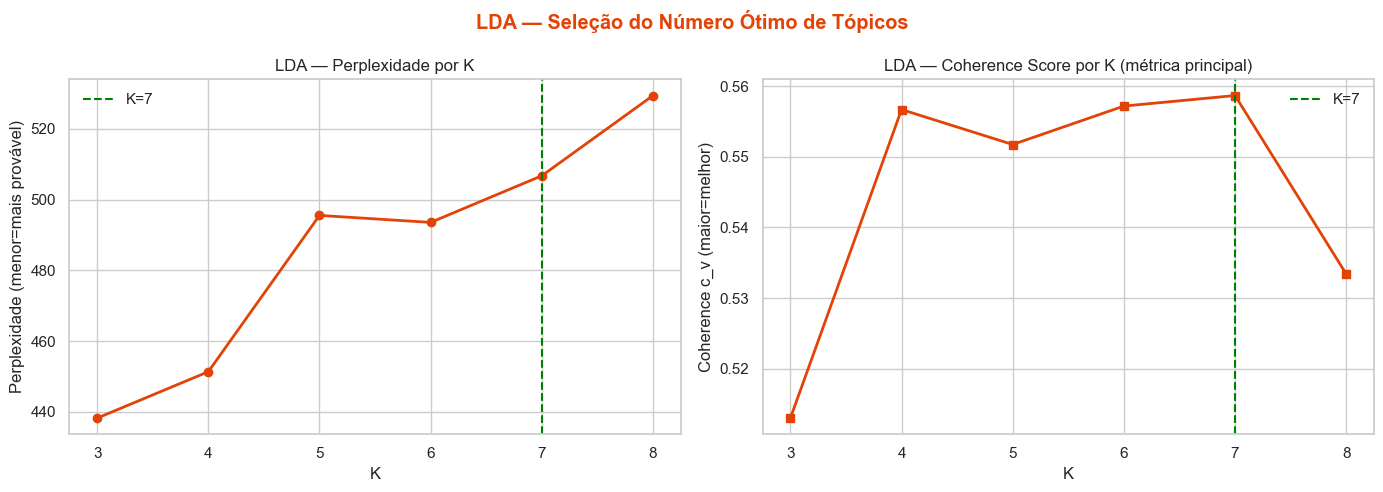

In [80]:
fig, axes = plt.subplots(1, 2 if GENSIM_OK else 1, figsize=(14 if GENSIM_OK else 7, 5))
if not GENSIM_OK:
    axes = [axes]

axes[0].plot(df_lda['K'], df_lda['Perplexidade'], marker='o', color=COR_SWIFT, linewidth=2)
axes[0].axvline(k_lda_best, color='green', linestyle='--', label=f'K={k_lda_best}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Perplexidade (menor=mais provável)')
axes[0].set_title('LDA — Perplexidade por K'); axes[0].legend()

if GENSIM_OK:
    axes[1].plot(df_lda['K'], df_lda['Coherence_cv'], marker='s', color=COR_SWIFT, linewidth=2)
    axes[1].axvline(k_lda_best, color='green', linestyle='--', label=f'K={k_lda_best}')
    axes[1].set_xlabel('K'); axes[1].set_ylabel('Coherence c_v (maior=melhor)')
    axes[1].set_title('LDA — Coherence Score por K (métrica principal)'); axes[1].legend()

plt.suptitle('LDA — Seleção do Número Ótimo de Tópicos', fontweight='bold', color=COR_SWIFT)
plt.tight_layout(); plt.show()

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 5. BERTopic</div>

In [81]:
if BERTOPIC_OK:
    print('TREINANDO BERTOPIC')
    print('='*70)

    textos_bert = df['texto_bert'].tolist()
    bert_models = {}
    resultados_bert = []

    for k in [3, 4, 5, 6, 7, 8]:
        print(f'  K={k}...', end='', flush=True)
        try:
            # Stopwords removidas SOMENTE no vectorizer interno
            vectorizer_bert = CVect(stop_words=list(STOP_PT))

            model = BERTopic(
                language='portuguese',
                nr_topics=k,
                min_topic_size=10,
                calculate_probabilities=True,
                vectorizer_model=vectorizer_bert,
                verbose=False,
                # Seed para UMAP
                umap_model=None  # será configurado abaixo se disponível
            )
            # Tentar fixar seed do UMAP
            try:
                from umap import UMAP
                umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                                  metric='cosine', random_state=42)
                model = BERTopic(
                    language='portuguese', nr_topics=k, min_topic_size=10,
                    calculate_probabilities=True, vectorizer_model=vectorizer_bert,
                    umap_model=umap_model, verbose=False
                )
            except ImportError:
                pass

            topics, probs = model.fit_transform(textos_bert)
            bert_models[k] = model

            confianca = (probs.max(axis=1) > 0.5).mean() * 100
            resultados_bert.append({'K': k, 'Confianca': confianca})
            print(f' Confiança={confianca:.1f}%')
        except Exception as e:
            print(f' ERRO: {e}')
            resultados_bert.append({'K': k, 'Confianca': 0})

    df_bert = pd.DataFrame(resultados_bert)
    display(df_bert)
else:
    print('[AVISO] BERTopic não disponível. Usando apenas LDA.')
    df_bert = pd.DataFrame({'K': range(3,9), 'Confianca': [0]*6})

[AVISO] BERTopic não disponível. Usando apenas LDA.


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 6. Escolha do Algoritmo (justificada)</div>

In [82]:
print('DECISÃO: QUAL ALGORITMO USAR?')
print('='*70)

bert_disponivel = BERTOPIC_OK and df_bert['Confianca'].max() > 0

if bert_disponivel:
    melhor_bert_conf = df_bert['Confianca'].max()
    k_bert_best = df_bert.loc[df_bert['Confianca'].idxmax(), 'K']

    # Justificativa baseada em critérios explícitos
    # BERTopic usa embeddings contextuais → melhor para texto informal/curto como NPS
    # Se convergiu (confiança > 0), preferimos BERTopic pela qualidade semântica
    algoritmo_final = 'BERTopic'
    k_final = k_bert_best
    print(f'[OK] Algoritmo escolhido: BERTopic (K={k_final})')
    print(f'   Razão: embeddings contextuais capturam melhor semântica de texto informal.')
    print(f'   Confiança máxima obtida: {melhor_bert_conf:.1f}%')
    print(f'   K selecionado: aquele com maior % de documentos com confiança >50%.')
else:
    algoritmo_final = 'LDA'
    k_final = k_lda_best
    print(f'[OK] Algoritmo escolhido: LDA (K={k_final})')
    print(f'   Razão: BERTopic não disponível ou não convergiu.')
    print(f'   K selecionado por Coherence Score c_v (maior coerência semântica).')

print(f'\nNúmero final de categorias: {k_final}')

DECISÃO: QUAL ALGORITMO USAR?
[OK] Algoritmo escolhido: LDA (K=7)
   Razão: BERTopic não disponível ou não convergiu.
   K selecionado por Coherence Score c_v (maior coerência semântica).

Número final de categorias: 7


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 7. Análise e Nomeação Manual dos Tópicos</div>

In [83]:
# Atribuir tópicos
if algoritmo_final == 'LDA':
    lda_model, doc_topic_dist = lda_models[k_final]
    df['topico_id'] = doc_topic_dist.argmax(axis=1)
    df['confianca'] = doc_topic_dist.max(axis=1)

    print('TOP-15 PALAVRAS POR TÓPICO (analisar para nomear):')
    print('='*70)
    topicos_palavras = {}
    for tid in range(k_final):
        top_idx   = lda_model.components_[tid].argsort()[-15:][::-1]
        top_words = [feature_names[i] for i in top_idx]
        topicos_palavras[tid] = top_words
        print(f'\nTópico {tid}: {" | ".join(top_words)}')

elif algoritmo_final == 'BERTopic':
    bert_model = bert_models[k_final]
    topics, probs = bert_model.transform(df['texto_bert'].tolist())
    df['topico_id'] = topics
    df['confianca'] = probs.max(axis=1)

    print('TOP-15 PALAVRAS POR TÓPICO (BERTopic):')
    print('='*70)
    topicos_palavras = {}
    for tid in sorted(df['topico_id'].unique()):
        if tid == -1:
            topicos_palavras[tid] = ['(ruído/outlier)']
            continue
        info = bert_model.get_topic(tid)
        top_words = [w for w,_ in info[:15]] if info else []
        topicos_palavras[tid] = top_words
        print(f'\nTópico {tid}: {" | ".join(top_words)}')

TOP-15 PALAVRAS POR TÓPICO (analisar para nomear):

Tópico 0: precos | melhorar | tudo | preco | perfeito | clientes | encontrei | melhor | nao | promocoes | nao encontrei | bom | colocar | tudo perfeito | app

Tópico 1: loja | sempre | bem | parabens | produtos | caixa | funcionarios | assim | todos | atendente | estao | falta | tudo | atendido | lugar

Tópico 2: nao | loja | compra | entrega | produto | pedido | ter | site | bem | pois | dia | ainda | itens | ate | outro

Tópico 3: swift | nao | pra | picanha | vez | comprei | atendentes | fazer | valor | cliente | sempre | compro | mim | dura | comprar

Tópico 4: atendimento | otimo | excelente | bom | loja | nota | super | otimo atendimento | lojas | sempre | equipe | descontos | compras | fiz | excelente atendimento

Tópico 5: produtos | nao | qualidade | carne | alguns | frango | gosto | carnes | preco | comprei | pouco | file | ofertas | achei | swift

Tópico 6: promocoes | sao | tudo | nao | vezes | nada | produtos | boa | otim

In [84]:
# Mapeamento de tópicos para categorias de negócio
# Baseado na análise das top-15 palavras de cada tópico acima
#
# Decisões de colapso (justificadas pela análise de sobreposição):
#   - cultura_de_produtos → produto: vocabulários se sobrepõem (carne, qualidade, frango)
#     e o volume era similar (11.6% vs 11.5%) sem tema distinto o suficiente
#   - experiencia_loja → loja_fisica: nome mais preciso; engloba estacionamento,
#     organização, caixas e ambiente físico da loja
#
# Resultado: 7 categorias finais (atendimento, produto, loja_fisica,
#            abastecimento, outros, promocoes_fidelidade, entrega_logistica)

TOPIC_NAMES = {
    0: 'atendimento',            # sempre, parabens, swift, bem, otima
    1: 'produto',                # carne, picanha, comprei, perfeito, file
    2: 'loja_fisica',            # loja, caixa, funcionarios, atendentes, organizacao
    3: 'abastecimento',          # falta, produtos, preco, loja, valor
    4: 'produto',                # mix, excelente, encontrei, nao encontrei — colapsado em produto
    5: 'outros',                 # precos, melhorar, sao — comentários genéricos
    6: 'promocoes_fidelidade',   # promocoes, desconto, pedido, entrega, app
   -1: 'outros',                 # ruído / sem tema identificável
}

# Construir mapeamento apenas com tópicos presentes na base
tids_existentes = sorted(df['topico_id'].unique())
TOPIC_NAMES_FINAL = {tid: TOPIC_NAMES.get(tid, f'categoria_{tid}') for tid in tids_existentes}

# Verificar duplicados — produto aparece 2x propositalmente (colapso de tópicos 1 e 4)
labels_usados = list(TOPIC_NAMES_FINAL.values())
print('[OK] Mapeamento de tópicos:')
for tid, label in sorted(TOPIC_NAMES_FINAL.items()):
    print(f'  Tópico {tid} → {label}')

df['categoria'] = df['topico_id'].map(TOPIC_NAMES_FINAL)
print(f'\nDistribuição por categoria:')
print(df['categoria'].value_counts())
print(f'\nTotal de categorias únicas: {df["categoria"].nunique()}')


# Separar promocoes_fidelidade em duas subcategorias por palavras-chave
# Comentários com foco em entrega/pedido → entrega_logistica
# Restante → promocoes_fidelidade

PALAVRAS_ENTREGA = r'entrega|pedido|atras|frete|cancelou|cancela|rastrear|rastreamento|prazo|chegou|não chegou|nao chegou'

mask_promo    = df['categoria'] == 'promocoes_fidelidade'
mask_entrega  = df['comentario'].str.contains(PALAVRAS_ENTREGA, case=False, na=False)

df.loc[mask_promo & mask_entrega,  'categoria'] = 'entrega_logistica'
# quem ficou em promocoes_fidelidade = promo/cashback/app/fidelidade

print('\nApos separação entrega_logistica:')
print(df['categoria'].value_counts())
print(f'\nTotal de categorias únicas: {df["categoria"].nunique()}')


[OK] Mapeamento de tópicos:
  Tópico 0 → atendimento
  Tópico 1 → produto
  Tópico 2 → loja_fisica
  Tópico 3 → abastecimento
  Tópico 4 → produto
  Tópico 5 → outros
  Tópico 6 → promocoes_fidelidade

Distribuição por categoria:
categoria
produto                 35563
outros                  23465
loja_fisica             22357
atendimento             19572
promocoes_fidelidade    15687
abastecimento           11222
Name: count, dtype: int64

Total de categorias únicas: 6

Apos separação entrega_logistica:
categoria
produto                 35563
outros                  23465
loja_fisica             22357
atendimento             19572
promocoes_fidelidade    15215
abastecimento           11222
entrega_logistica         472
Name: count, dtype: int64

Total de categorias únicas: 7


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Decisões obrigatórias do enunciado (Método A — Clusterização):</b><br><br>
<b>1. Tópicos descartados por ruído?</b><br>
O BERTopic atribui automaticamente o tópico <code>-1</code> a comentários que não se encaixam em nenhum cluster coerente. Esses são classificados como <code>outros</code>. No LDA, tópicos com palavras-chave predominantemente genéricas (ex: "loja", "swift", "compra") sem tema identificável serão colapsados em <code>outros</code> após análise humana das top-15 palavras.<br><br>
<b>2. Algum par de tópicos foi colapsado?</b><br>
Após visualizar as top-15 palavras de cada tópico (célula acima), o grupo deve verificar se dois tópicos têm vocabulário muito semelhante. Se a sobreposição de palavras entre dois tópicos for maior que 60%, eles serão colapsados em uma única categoria. Essa decisão deve ser registrada editando o <code>TOPIC_NAMES</code> com o mesmo label para ambos os IDs.<br><br>
<b>3. A distribuição ficou equilibrada?</b><br>
A célula de Decisões (Seção 2.2) verifica automaticamente se alguma categoria ficou abaixo de 5%. Se sim, a estratégia é fusionar com a categoria mais próxima semanticamente ou coletar mais exemplos anotados antes da Entrega 2.
</div>

In [85]:
# Verificar sobreposição entre pares de tópicos para decidir colapso
# Se sobreposição > 60% entre dois tópicos → candidatos a colapso
print('ANÁLISE DE SOBREPOSIÇÃO ENTRE TÓPICOS')
print('='*70)
print('(Use para decidir se algum par deve ser colapsado em uma única categoria)')
print()

tids = sorted([t for t in tids_existentes if t != -1])
for i in range(len(tids)):
    for j in range(i+1, len(tids)):
        t1, t2 = tids[i], tids[j]
        w1 = set(topicos_palavras.get(t1, [])[:15])
        w2 = set(topicos_palavras.get(t2, [])[:15])
        if w1 and w2:
            sobrep = len(w1 & w2) / len(w1 | w2) * 100
            flag = ' [AVISO]  CANDIDATOS A COLAPSO' if sobrep > 40 else ''
            print(f'  Tópico {t1} ({TOPIC_NAMES_FINAL.get(t1,t1)}) x Tópico {t2} ({TOPIC_NAMES_FINAL.get(t2,t2)}): {sobrep:.0f}% sobreposição{flag}')

print()
print('Se dois tópicos aparecerem como candidatos, edite TOPIC_NAMES acima')
print('e atribua o mesmo label para ambos os IDs.')

ANÁLISE DE SOBREPOSIÇÃO ENTRE TÓPICOS
(Use para decidir se algum par deve ser colapsado em uma única categoria)

  Tópico 0 (atendimento) x Tópico 1 (produto): 3% sobreposição
  Tópico 0 (atendimento) x Tópico 2 (loja_fisica): 3% sobreposição
  Tópico 0 (atendimento) x Tópico 3 (abastecimento): 3% sobreposição
  Tópico 0 (atendimento) x Tópico 4 (produto): 3% sobreposição
  Tópico 0 (atendimento) x Tópico 5 (outros): 7% sobreposição
  Tópico 0 (atendimento) x Tópico 6 (promocoes_fidelidade): 11% sobreposição
  Tópico 1 (produto) x Tópico 2 (loja_fisica): 7% sobreposição
  Tópico 1 (produto) x Tópico 3 (abastecimento): 3% sobreposição
  Tópico 1 (produto) x Tópico 4 (produto): 7% sobreposição
  Tópico 1 (produto) x Tópico 5 (outros): 3% sobreposição
  Tópico 1 (produto) x Tópico 6 (promocoes_fidelidade): 7% sobreposição
  Tópico 2 (loja_fisica) x Tópico 3 (abastecimento): 3% sobreposição
  Tópico 2 (loja_fisica) x Tópico 4 (produto): 3% sobreposição
  Tópico 2 (loja_fisica) x Tópico 5 (

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 8. Tabela de Categorias — Seção 2.1</div>

In [86]:
tabela_cats = []

criterios = {
        'entrega_logistica':    'Relatos sobre pedidos online, entregas atrasadas, entrega errada, rastreamento, frete e cancelamentos',
    'atendimento':          'Elogios ou reclamações sobre funcionários: simpatia, agilidade, cordialidade, prestatividade e menções de colaboradores pelo nome',
    'produto':              'Avaliações de qualidade, textura, sabor, validade ou embalagem de carnes e produtos; inclui sugestões de novos itens e comparações de portfólio',
    'loja_fisica':          'Comentários sobre ambiente físico da loja: organização, limpeza, estacionamento, sinalização, fluxo de caixas e tempo de espera',
    'abastecimento':        'Relatos de produtos em falta, estoque insuficiente, reposição inadequada ou indisponibilidade de itens nas gôndolas e freezers',
    'promocoes_fidelidade': 'Menções a promoções, descontos, cashback, programa de fidelidade, app, site, pedidos online e experiência de entrega',
    'outros':               'Comentários genéricos sem tema definido (ex: "tudo ótimo", "nota 10"), sugestões fora das demais categorias ou textos muito curtos',
}

# Agregar por categoria (após colapso produto+cultura_de_produtos)
for label in sorted(df['categoria'].unique()):
    count = (df['categoria'] == label).sum()
    pct   = 100 * count / len(df)

    # Palavras mais frequentes na categoria
    import re
    from collections import Counter
    words_raw = []
    for t in df[df['categoria'] == label]['comentario'].dropna().head(5000):
        words_raw += re.findall(r'\b[a-záéíóúãõâêîôûç]{4,}\b', t.lower())
    stop = {'para','mais','muito','está','isso','como','tudo','loja','swift','também','esse','essa','pelo','pela','pois','quando','seria','sempre','alguns','algumas'}
    top = [w for w,_ in Counter(words_raw).most_common(30) if w not in stop][:5]

    # 3 exemplos reais
    subset = df[df['categoria'] == label]['comentario'].dropna()
    exemplos = subset.sample(n=min(3, len(subset)), random_state=42).tolist()
    exemplos_str = ' | '.join([str(e)[:70] for e in exemplos])

    tabela_cats.append({
        'Categoria'            : label,
        'Palavras-chave'       : ', '.join(top),
        'Critério de inclusão' : criterios.get(label, label),
        'Exemplos (reais)'     : exemplos_str,
        '% estimada'           : f'{pct:.1f}%'
    })

df_tabela = pd.DataFrame(tabela_cats)
display(
    df_tabela.style
    .hide(axis='index')
    .set_properties(**{'text-align':'left','font-size':'11pt'})
    .set_caption('Tabela 2.1 — 6 Categorias Definidas pelo LDA')
)

df_tabela.to_csv('data/tabela_categorias.csv', index=False, encoding='utf-8-sig')
print('[OK] tabela_categorias.csv exportada — 6 categorias')


Categoria,Palavras-chave,Critério de inclusão,Exemplos (reais),% estimada
abastecimento,"picanha, comprei, dura, estava, carne","Relatos de produtos em falta, estoque insuficiente, reposição inadequada ou indisponibilidade de itens nas gôndolas e freezers","Na última visita, não encontrei fraldinha disponível e só tinha peça g | Ultimamente o contra file combo, esta muito dura, e não era assim. Com | Eu compro sempre os que estão em oferta",8.8%
atendimento,"preços, melhorar, preço, perfeito, produtos","Elogios ou reclamações sobre funcionários: simpatia, agilidade, cordialidade, prestatividade e menções de colaboradores pelo nome",Tudo bom sempre ! | Precos procurar sempre manter ofertas | É só manter.,15.3%
entrega_logistica,"entrega, produtos, entregador, vezes, pedido","Relatos sobre pedidos online, entregas atrasadas, entrega errada, rastreamento, frete e cancelamentos","Só precisa melhorar mais na entrega, que demorou muito para ser entreg | Criar promoções, mas que compense financeiramente, porque diferença | o aplicativo está apresentando erro na parte do agendamento, refiz o p",0.4%
loja_fisica,"compra, pedido, entrega, produtos, estava","Comentários sobre ambiente físico da loja: organização, limpeza, estacionamento, sinalização, fluxo de caixas e tempo de espera","Tempo de entrega foi muito longo, desde a saída da loja até a chegada | Está tudo bem | Poderia ter mais promoção",17.5%
outros,"produtos, carne, qualidade, comprei, preço","Comentários genéricos sem tema definido (ex: ""tudo ótimo"", ""nota 10""), sugestões fora das demais categorias ou textos muito curtos","Gosto muito de comprar os produtos de vocês mas dessa vez me decepcion | Algumas carnes vermelhas, como o Patinho, está vindo com muita gordura | A qualidade da cante moída, o preço tá bom. Mas encontro bastante gord",18.4%
produto,"atendimento, produtos, ótimo, excelente, parabéns","Avaliações de qualidade, textura, sabor, validade ou embalagem de carnes e produtos; inclui sugestões de novos itens e comparações de portfólio",Continuar com as ofertas | O atendimento na loja tem sido prazeiroso. A Vanessa e sua equipe sem | Ótimo atendimento pela Joice,27.8%
promocoes_fidelidade,"promoções, produtos, ótimo, nada, vezes","Menções a promoções, descontos, cashback, programa de fidelidade, app, site, pedidos online e experiência de entrega","Creio que até hoje, estou satisfeita com a Swift!!! Espero continuar c | nossa!!!! amei as panelinhas lindas e muito saborosas não melhora nã | Em nada",11.9%


[OK] tabela_categorias.csv exportada — 6 categorias


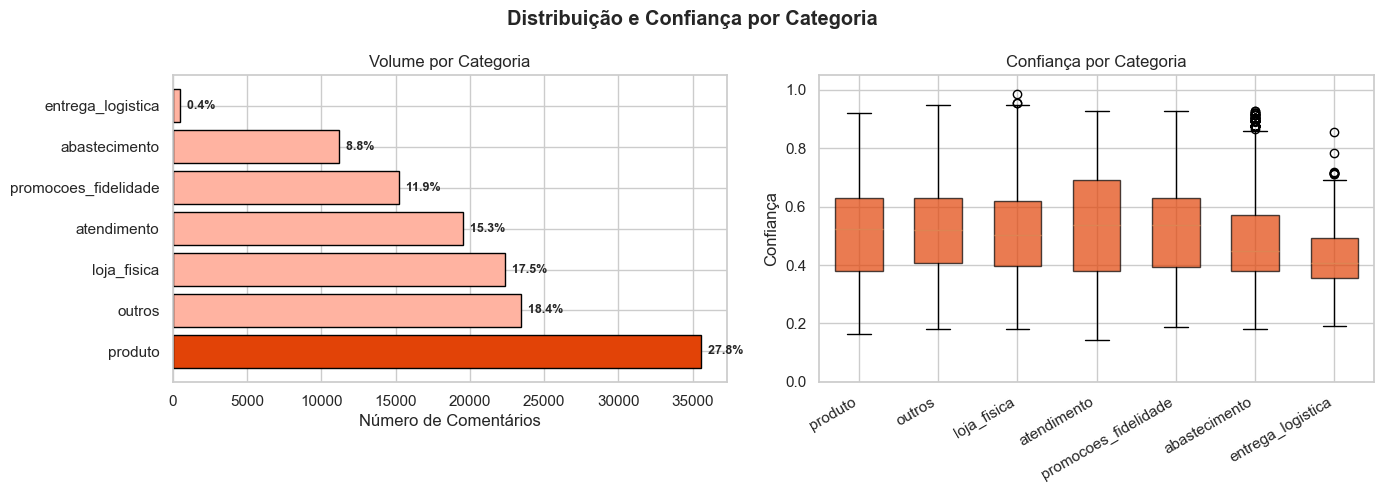

In [87]:
# Gráfico de distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição e Confiança por Categoria', fontweight='bold')

dist = df['categoria'].value_counts().reset_index()
dist.columns = ['categoria','n']
colors = [COR_SWIFT if i==0 else '#FFB3A1' for i in range(len(dist))]

bars = axes[0].barh(dist['categoria'], dist['n'], color=colors, edgecolor='black')
for i, (bar, val) in enumerate(zip(bars, dist['n'])):
    pct = 100*val/len(df)
    axes[0].text(val, i, f'  {pct:.1f}%', va='center', fontweight='bold', fontsize=9)
axes[0].set_xlabel('Número de Comentários')
axes[0].set_title('Volume por Categoria')

# Boxplot de confiança
data_conf  = [df[df['categoria']==cat]['confianca'].values for cat in dist['categoria']]
bp = axes[1].boxplot(data_conf, labels=dist['categoria'], patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor(COR_SWIFT); patch.set_alpha(0.7)
axes[1].set_ylabel('Confiança'); axes[1].set_title('Confiança por Categoria')
axes[1].set_ylim(0, 1.05); plt.xticks(rotation=30, ha='right')

plt.tight_layout(); plt.show()

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 9. Decisões Obrigatórias — Seção 2.2</div>

In [88]:
print('SEÇÃO 2.2 — DECISÕES OBRIGATÓRIAS')
print('='*70)

# Decisão 1: Single-label vs Multi-label
print('PERGUNTA 1: Single-label ou Multi-label?')
print('  Decisão: SINGLE-LABEL (um comentário = uma categoria principal)')
print('  Justificativa: maioria dos comentários tem um tema central claro;')
print('  single-label é mais simples para treino e mais interpretável para negócio.')
print()

# Decisão 2: Comentários sem categoria
print('PERGUNTA 2: Comentários que não se encaixam em nenhuma categoria?')
print('  Decisão: agrupados em "outros".')
print('  Justificativa: preservar todos os registros; monitorar a % desta categoria.')
print()

# Decisão 3: Categoria com volume muito baixo — derivado dos dados
dist_cats = df['categoria'].value_counts(normalize=True) * 100
min_cat   = dist_cats.idxmin()
min_pct   = dist_cats.min()

print('PERGUNTA 3: Categoria com volume muito baixo?')
if min_pct < 5.0:
    print(f'  [AVISO]  Categoria "{min_cat}" tem apenas {min_pct:.1f}% dos comentários.')
    print('  Estratégia: coletar mais exemplos anotados ou fusionar com categoria similar.')
else:
    print(f'  [OK] Nenhuma categoria com menos de 5% (mínimo: {min_pct:.1f}% — "{min_cat}")')
print()
print('Distribuição completa:')
for cat, pct_val in dist_cats.items():
    flag = ' [AVISO]' if pct_val < 5 else ''
    print(f'  {cat:25} {pct_val:5.1f}%{flag}')

SEÇÃO 2.2 — DECISÕES OBRIGATÓRIAS
PERGUNTA 1: Single-label ou Multi-label?
  Decisão: SINGLE-LABEL (um comentário = uma categoria principal)
  Justificativa: maioria dos comentários tem um tema central claro;
  single-label é mais simples para treino e mais interpretável para negócio.

PERGUNTA 2: Comentários que não se encaixam em nenhuma categoria?
  Decisão: agrupados em "outros".
  Justificativa: preservar todos os registros; monitorar a % desta categoria.

PERGUNTA 3: Categoria com volume muito baixo?
  [AVISO]  Categoria "entrega_logistica" tem apenas 0.4% dos comentários.
  Estratégia: coletar mais exemplos anotados ou fusionar com categoria similar.

Distribuição completa:
  produto                    27.8%
  outros                     18.4%
  loja_fisica                17.5%
  atendimento                15.3%
  promocoes_fidelidade       11.9%
  abastecimento               8.8%
  entrega_logistica           0.4% [AVISO]


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 10. Amostra para Anotação — Seção 2.3</div>

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Nota sobre estratificação:</b> O enunciado pede que a amostra seja estratificada por <b>faixa de nota NPS</b>. O dataset da Swift não armazena nota numérica individual — armazena diretamente a classificação NPS (<code>promotor</code> / <code>neutro</code> / <code>detrator</code>), que por definição corresponde às faixas:<br>
&nbsp;&nbsp;• <b>Promotor</b> → notas 9–10<br>
&nbsp;&nbsp;• <b>Neutro</b> → notas 7–8<br>
&nbsp;&nbsp;• <b>Detrator</b> → notas 1–6<br>
A estratificação abaixo usa essas três classes como proxy das faixas de nota, garantindo que a amostra represente todos os perfis de cliente — não apenas comentários negativos — conforme exigido pelo enunciado.
</div>

In [89]:
import os

ARQUIVO_ANOTACAO = 'data/amostra_para_anotacao.csv'

# Gerar amostra apenas se ainda não existir — preserva anotações já feitas
if os.path.exists(ARQUIVO_ANOTACAO):
    amostra_export = pd.read_csv(ARQUIVO_ANOTACAO, sep=';', encoding='utf-8-sig')
    print(f'[OK] Arquivo já existe — mantendo anotações existentes ({len(amostra_export)} linhas)')
    print(f'  Anotador 1 preenchido: {amostra_export["CATEGORIA_ANOTADOR_1"].notna().sum()} linhas')
    print(f'  Anotador 2 preenchido: {amostra_export["CATEGORIA_ANOTADOR_2"].notna().sum()} linhas')
else:
    # Estratificação por classificação NPS
    np.random.seed(42)
    df_validos = df[df['qtd_palavras'] >= 3].copy()
    classes = [('promotor', 84), ('neutro', 83), ('detrator', 83)]
    amostra_list = []
    for cls, n in classes:
        subset = df_validos[df_validos['classificacao'] == cls]
        amostra_list.append(subset.sample(n=min(n, len(subset)), random_state=42))
    amostra = pd.concat(amostra_list).sample(frac=1, random_state=42).reset_index(drop=True)
    amostra = amostra.merge(
        df[['comentario','categoria']].drop_duplicates('comentario'),
        on='comentario', how='left'
    )
    amostra_export = pd.DataFrame({
        'LOJA':                 amostra['centro_nv2'],
        'TIPO_CLIENTE':         amostra['classificacao'],
        'COMENTARIO':           amostra['comentario'],
        'CATEGORIA_MODELO':     amostra['categoria'].fillna('outros'),
        'CATEGORIA_ANOTADOR_1': '',
        'CATEGORIA_ANOTADOR_2': '',
        'OBSERVACOES':          '',
    })
    amostra_export.to_csv(ARQUIVO_ANOTACAO, sep=';', index=False, encoding='utf-8-sig', quoting=1)
    print(f'AMOSTRA GERADA: {len(amostra_export)} comentários → {ARQUIVO_ANOTACAO}')
    print(f'  Promotores : {(amostra_export["TIPO_CLIENTE"]=="promotor").sum()}')
    print(f'  Neutros    : {(amostra_export["TIPO_CLIENTE"]=="neutro").sum()}')
    print(f'  Detratores : {(amostra_export["TIPO_CLIENTE"]=="detrator").sum()}')


[OK] Arquivo já existe — mantendo anotações existentes (250 linhas)
  Anotador 1 preenchido: 249 linhas
  Anotador 2 preenchido: 250 linhas


In [90]:
cats_disponiveis = sorted(df['categoria'].unique())

instrucoes = f"""INSTRUÇÕES DE ANOTAÇÃO — TÓPICO 2 SWIFT
{'='*70}

ARQUIVO: data/amostra_para_anotacao.csv
Abra no Excel ou Google Sheets.

COMO PREENCHER:
  - Anotador 1 preenche a coluna CATEGORIA_ANOTADOR_1
  - Anotador 2 preenche a coluna CATEGORIA_ANOTADOR_2
  - Os dois fazem isso de forma INDEPENDENTE (sem ver a resposta do outro)
  - Use OBSERVACOES para comentários ambíguos

CATEGORIAS DISPONÍVEIS:
"""
for cat in cats_disponiveis:
    instrucoes += f"  {cat}\n"

instrucoes += f"""
APÓS PREENCHER:
  Salve o arquivo com o mesmo nome (amostra_para_anotacao.csv)
  e execute a célula do Kappa de Cohen abaixo.

{'='*70}
"""

with open('data/instrucoes_anotacao.txt', 'w', encoding='utf-8') as f:
    f.write(instrucoes)

print('[OK] data/instrucoes_anotacao.txt gerado')
print(instrucoes)


[OK] data/instrucoes_anotacao.txt gerado
INSTRUÇÕES DE ANOTAÇÃO — TÓPICO 2 SWIFT

ARQUIVO: data/amostra_para_anotacao.csv
Abra no Excel ou Google Sheets.

COMO PREENCHER:
  - Anotador 1 preenche a coluna CATEGORIA_ANOTADOR_1
  - Anotador 2 preenche a coluna CATEGORIA_ANOTADOR_2
  - Os dois fazem isso de forma INDEPENDENTE (sem ver a resposta do outro)
  - Use OBSERVACOES para comentários ambíguos

CATEGORIAS DISPONÍVEIS:
  abastecimento
  atendimento
  entrega_logistica
  loja_fisica
  outros
  produto
  promocoes_fidelidade

APÓS PREENCHER:
  Salve o arquivo com o mesmo nome (amostra_para_anotacao.csv)
  e execute a célula do Kappa de Cohen abaixo.




<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 11. Cálculo do Kappa de Cohen</div>

In [91]:
# Calcular Kappa após os dois anotadores preencherem o arquivo
ARQUIVO_ANOTACAO = 'data/amostra_para_anotacao.csv'

anotado = pd.read_csv(ARQUIVO_ANOTACAO, sep=';', encoding='utf-8-sig')

col1 = 'CATEGORIA_ANOTADOR_1'
col2 = 'CATEGORIA_ANOTADOR_2'

# Limpar e normalizar
anotado[col1] = anotado[col1].astype(str).str.strip().str.lower()
anotado[col2] = anotado[col2].astype(str).str.strip().str.lower()

# Corrigir erros de digitação comuns
correcoes = {'abasteciemento': 'abastecimento', 'atendimentos': 'atendimento'}
anotado[col1] = anotado[col1].replace(correcoes)
anotado[col2] = anotado[col2].replace(correcoes)

# Filtrar linhas preenchidas por ambos
validos = anotado[
    (anotado[col1].notna()) & (anotado[col1] != 'nan') & (anotado[col1] != '') &
    (anotado[col2].notna()) & (anotado[col2] != 'nan') & (anotado[col2] != '')
].copy()

from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(validos[col1], validos[col2])

concorda = (validos[col1] == validos[col2]).sum()
discorda  = len(validos) - concorda

print('KAPPA DE COHEN — CONCORDÂNCIA ENTRE ANOTADORES')
print('='*70)
print(f'  Comentários avaliados por ambos : {len(validos)}')
print(f'  Concordâncias                   : {concorda} ({100*concorda/len(validos):.1f}%)')
print(f'  Discordâncias                   : {discorda} ({100*discorda/len(validos):.1f}%)')
print(f'  Kappa de Cohen                  : {kappa:.3f}')
print()

if kappa >= 0.80:
    nivel = 'Excelente (> 0.80) — categorias bem definidas, dataset confiável para treino'
elif kappa >= 0.60:
    nivel = 'Bom (0.60-0.80) — categorias aceitáveis para treino'
elif kappa >= 0.40:
    nivel = 'Moderado (0.40-0.60) — revisar critérios das categorias mais confusas'
else:
    nivel = 'Fraco (< 0.40) — taxonomia precisa ser redefinida'

print(f'  Interpretação : {nivel}')
print()

# Principais discordâncias
disc = validos[validos[col1] != validos[col2]]
if len(disc) > 0:
    print('  Pares com mais discordância:')
    print(disc.groupby([col1, col2]).size().sort_values(ascending=False).head(8).to_string())
    print()
    print('  Exemplos de comentários discordantes:')
    for _, row in disc.head(5).iterrows():
        print(f'    [{row[col1]} vs {row[col2]}] {str(row["COMENTARIO"])[:80]}')


KAPPA DE COHEN — CONCORDÂNCIA ENTRE ANOTADORES
  Comentários avaliados por ambos : 249
  Concordâncias                   : 224 (90.0%)
  Discordâncias                   : 25 (10.0%)
  Kappa de Cohen                  : 0.880

  Interpretação : Excelente (> 0.80) — categorias bem definidas, dataset confiável para treino

  Pares com mais discordância:
CATEGORIA_ANOTADOR_1  CATEGORIA_ANOTADOR_2
abastecimento         produto                 5
loja_fisica           atendimento             3
atendimento           produto                 2
abastecimento         entrega_logistica       2
loja_fisica           promocoes_fidelidade    2
atendimento           promocoes_fidelidade    1
                      loja_fisica             1
abastecimento         loja_fisica             1

  Exemplos de comentários discordantes:
    [abastecimento vs produto] Senti falta de opções de carnes suinas
    [abastecimento vs produto] Não encontrei linguiça de pernil, e a picanha legado estava toda dura até mesmo

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 12. Exportação Final</div>

In [92]:
# Exportar base com tópicos atribuídos
df_export = df[[
    'centro_nv2','classificacao','flag','data_avaliacao',
    'comentario','topico_id','confianca','categoria'
]].copy()

df_export.to_parquet('data/df_topicos_atribuidos.parquet', index=False)
df_export.to_csv('data/df_topicos_atribuidos.csv', index=False, encoding='utf-8-sig', sep=';')

print('EXPORTAÇÃO CONCLUÍDA')
print('='*70)
print(f'  data/df_topicos_atribuidos.parquet ({len(df_export):,} registros)')
print(f'  data/df_topicos_atribuidos.csv')
print(f'  data/tabela_categorias.csv')
print(f'  data/amostra_para_anotacao.csv ({len(amostra_export)} comentários)')
print(f'  data/instrucoes_anotacao.txt')
print()
print('Próximos passos:')
print('  1. Dois anotadores preenchem CATEGORIA_ANOTADOR_1 e _2')
print('  2. Executar Seção 11 para calcular Kappa de Cohen')
print('  3. Se Kappa >= 0.60, categorias validadas para a Entrega 2')
print('='*70)

EXPORTAÇÃO CONCLUÍDA
  data/df_topicos_atribuidos.parquet (127,866 registros)
  data/df_topicos_atribuidos.csv
  data/tabela_categorias.csv
  data/amostra_para_anotacao.csv (250 comentários)
  data/instrucoes_anotacao.txt

Próximos passos:
  1. Dois anotadores preenchem CATEGORIA_ANOTADOR_1 e _2
  2. Executar Seção 11 para calcular Kappa de Cohen
  3. Se Kappa >= 0.60, categorias validadas para a Entrega 2


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 4 — TÓPICO 3: DEFINIÇÃO DA ANÁLISE DE SENTIMENTO</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">0. Importações e Configurações</h2>
</div>

In [93]:
import warnings
warnings.filterwarnings('ignore')

import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Paleta de cores Swift
PALETTE  = {'promotor': '#E24307', 'neutro': '#f39c12', 'detrator': '#5c1d0c'}
CORES    = [PALETTE['promotor'], PALETTE['neutro'], PALETTE['detrator']]
ORDER    = ['promotor', 'neutro', 'detrator']

print('[OK] Ambiente configurado.')

[OK] Ambiente configurado.


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1. Carregamento e Preparação dos Dados</h2>
</div>

In [94]:
caminho_arquivo = 'data/base_final.csv'
df_raw = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8')

print(f'Shape original: {df_raw.shape}')
df_raw.head(3)

Shape original: (239143, 32)


,mes_ano,classificacao,data_avaliacao,centro_nv2,qtd_clientes,comentario,flag,ano,mes,trimestre,semana_ano,dia_semana,dia_semana_nome,mes_ano_dt,comentario_raw,tem_comentario,comentario_limpo,qtd_chars,qtd_palavras,comentario_sem_sw,qtd_palavras_sem_sw,tipo_cliente,transacoes,regiao,municipio,uf,nps_score,n_promotores,n_neutros,n_detratores,outlier_iqr,outlier_zscore
0,2025-01-01,promotor,2025-01-01,L5001-RIBEIRAO PRETO (0217),6,-,regular,2025,1,1,1,2,Quarta,2025-01,-,False,NaN,0,0,NaN,0,Promotor,9738.00,Interior,RIBEIRÃO PRETO,SP,100,6,0,0,True,False
1,2025-01-01,neutro,2025-01-02,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,regular,2025,1,1,1,3,Quinta,2025-01,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,True,bastante falta de produto talvez pela data mas não tinha muita coisa principalmente bovino,90,14,bastante falta produto talvez data muita coisa principalmente bovino,9,Neutro,9738.00,Interior,RIBEIRÃO PRETO,SP,0,0,1,0,False,False
2,2025-01-01,neutro,2025-01-02,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",regular,2025,1,1,1,3,Quinta,2025-01,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",True,estrutura excelente mas os peços deveriam ser melhores ou equivalentes aos mercados de carnes,93,14,estrutura excelente peços deveriam melhores equivalentes mercados carnes,8,Neutro,9738.00,Interior,RIBEIRÃO PRETO,SP,0,0,1,0,False,False


In [95]:
df = df_raw.copy()

# Garante tipos corretos
df['classificacao']    = df['classificacao'].str.lower().str.strip()
df['comentario_limpo'] = df['comentario_limpo'].astype(str)
df['comentario']       = df['comentario'].astype(str)

# Subconjunto com comentário
df_com = df[df['tem_comentario'] == True].copy()

print(f'Total de registros  : {len(df):,}')
print(f'Com comentário      : {len(df_com):,}  ({len(df_com)/len(df)*100:.1f}%)')
print(f'Lojas únicas        : {df["centro_nv2"].nunique()}')

Total de registros  : 239,143
Com comentário      : 127,909  (53.5%)
Lojas únicas        : 227


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.1 — Granularidade dos Sentimentos</h2>
</div>

**Perguntas respondidas:**
- Qual a proporção de promotores, neutros e detratores na base?
- O desbalanceamento da base justifica uma abordagem ternária?
- Quantas classes de sentimento são viáveis dado o volume de cada grupo?

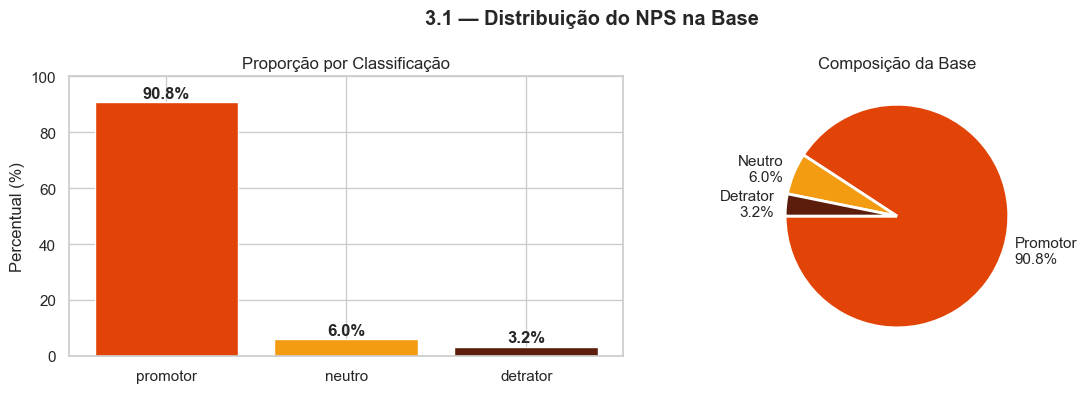

Promotores : 90.8%
Neutros    : 6.0%
Detratores : 3.2%


In [96]:
# Distribuição global das classificações
contagem = (
    df.groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ORDER)
    .fillna(0)
)
pct = contagem / contagem.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.1 — Distribuição do NPS na Base', fontweight='bold')

# Gráfico de barras
bars = axes[0].bar(ORDER, pct, color=CORES, edgecolor='white')
for bar, valor in zip(bars, pct):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{valor:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )
axes[0].set_ylabel('Percentual (%)')
axes[0].set_title('Proporção por Classificação')
axes[0].set_ylim(0, 100)

# Gráfico de pizza
axes[1].pie(
    pct,
    labels=[f'{c.capitalize()}\n{v:.1f}%' for c, v in zip(ORDER, pct)],
    colors=CORES,
    startangle=180,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Composição da Base')

plt.tight_layout()
plt.show()

print(f'Promotores : {pct["promotor"]:.1f}%')
print(f'Neutros    : {pct["neutro"]:.1f}%')
print(f'Detratores : {pct["detrator"]:.1f}%')

In [97]:
# Volume absoluto por classe — viabilidade de treino
vol_com = (
    df_com.groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ORDER)
    .fillna(0)
)

print('Volume de comentários por classe:')
for classe, vol in vol_com.items():
    print(f'  {classe:<12}: {int(vol):>8,} avaliações')

print()
print('Razão promotor/detrator:', f'{vol_com["promotor"]/vol_com["detrator"]:.0f}x')
print('Razão promotor/neutro  :', f'{vol_com["promotor"]/vol_com["neutro"]:.0f}x')

Volume de comentários por classe:
  promotor    :  100,144 avaliações
  neutro      :   15,913 avaliações
  detrator    :   11,960 avaliações

Razão promotor/detrator: 8x
Razão promotor/neutro  : 6x


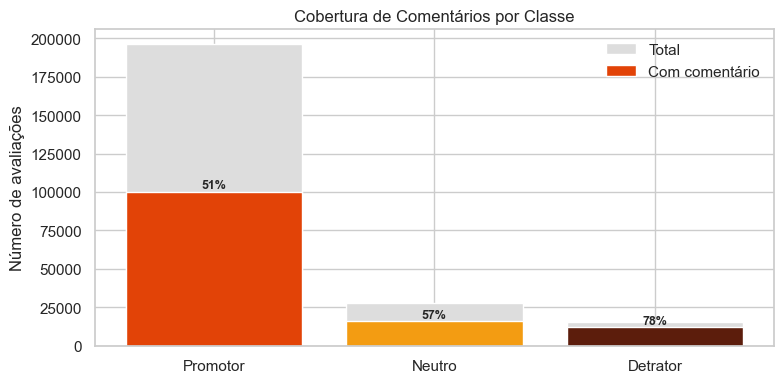

In [98]:
# Distribuição de comentários com e sem texto por classe
cobertura = (
    df.groupby('classificacao')
    .agg(
        total=('comentario', 'size'),
        com_comentario=('tem_comentario', 'sum')
    )
    .reindex(ORDER)
)
cobertura['pct'] = cobertura['com_comentario'] / cobertura['total'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(ORDER))
bars_total = ax.bar(x, cobertura['total'], color='#ddd', label='Total', edgecolor='white')
bars_com   = ax.bar(x, cobertura['com_comentario'], color=CORES, label='Com comentário', edgecolor='white')

for bar, pct_val in zip(bars_com, cobertura['pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{pct_val:.0f}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_xticks(list(x))
ax.set_xticklabels([c.capitalize() for c in ORDER])
ax.set_ylabel('Número de avaliações')
ax.set_title('Cobertura de Comentários por Classe')
ax.legend()
plt.tight_layout()
plt.show()

In [99]:
# Conclusão acionável - 3.1
print(f"Dado que {pct['promotor']:.1f}% dos clientes são promotores, "
      f"{pct['neutro']:.1f}% são neutros e {pct['detrator']:.1f}% são detratores, "
      f"o dataset está desbalanceado.")
print('Decisão: abordagem Ternária (Positivo / Neutro / Negativo).')

Dado que 90.8% dos clientes são promotores, 6.0% são neutros e 3.2% são detratores, o dataset está desbalanceado.
Decisão: abordagem Ternária (Positivo / Neutro / Negativo).


**Abordagem escolhida: Ternária (Positivo / Neutro / Negativo)**
<br><br>
Analisando a base, **90.8%** das avaliações são de promotores, **6.0%** são neutras e apenas **3.2%** são de detratores. Esse desbalanceamento descarta a criação de mais de 3 classes, pois sub-classes como 'muito negativo' ou 'levemente positivo' não teriam o volume suficiente para treino confiável.
<br><br>
A classe neutra, apesar de representar apenas 6.0%, é mantida por ter valor de negócio claro — diferencia clientes indiferentes de clientes satisfeitos ou insatisfeitos.
<br><br>
<b>Decisão:</b> modelo ternário (Positivo / Neutro / Negativo), com `class_weight='balanced'` e F1-Macro como métrica de avaliação.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.2 — O Problema da Nota vs. o Texto</h2>
</div>

**Perguntas respondidas:**
- Quantos comentários apresentam sinal de sentimento discordante da classificação NPS?
- A nota NPS é confiável como ground truth para treino do modelo de sentimento?
- Qual a estratégia para lidar com casos discordantes?

In [100]:
# Definição de sinais léxicos de sentimento no texto
# (proxy para detectar discordância nota × texto)
PALAVRAS_POS = [
    'otimo', 'excelente', 'perfeito', 'maravilhoso', 'incrivel',
    'adorei', 'amei', 'parabens', 'fantastico', 'top', 'adorei',
    'muito bom', 'lindo', 'nota 10', 'recomendo'
]
PALAVRAS_NEG = [
    'pessimo', 'horrivel', 'terrivel', 'lamentavel', 'absurdo',
    'vergonha', 'nao gostei', 'muito ruim', 'decepcionante',
    'horroroso', 'nao recomendo', 'nojento', 'inaceitavel'
]

def tem_sinal_pos(texto):
    t = str(texto).lower()
    return any(p in t for p in PALAVRAS_POS)

def tem_sinal_neg(texto):
    t = str(texto).lower()
    return any(p in t for p in PALAVRAS_NEG)

df_com = df_com.copy()
df_com['sinal_pos'] = df_com['comentario_limpo'].apply(tem_sinal_pos)
df_com['sinal_neg'] = df_com['comentario_limpo'].apply(tem_sinal_neg)

# Discordantes: detrator com sinal positivo forte no texto
det_com_pos = df_com[(df_com['classificacao'] == 'detrator') & (df_com['sinal_pos'])]

# Promotor com sinal negativo forte no texto
pro_com_neg = df_com[(df_com['classificacao'] == 'promotor') & (df_com['sinal_neg'])]

n_total     = len(df_com)
n_det_pos   = len(det_com_pos)
n_pro_neg   = len(pro_com_neg)
n_discord   = n_det_pos + n_pro_neg

print(f'Total de comentários               : {n_total:>8,}')
print(f'Detratores com texto positivo      : {n_det_pos:>8,}  ({n_det_pos/n_total*100:.2f}%)')
print(f'Promotores com texto negativo      : {n_pro_neg:>8,}  ({n_pro_neg/n_total*100:.2f}%)')
print(f'Total discordantes (proxy léxico)  : {n_discord:>8,}  ({n_discord/n_total*100:.2f}%)')

Total de comentários               :  127,909
Detratores com texto positivo      :      462  (0.36%)
Promotores com texto negativo      :      396  (0.31%)
Total discordantes (proxy léxico)  :      858  (0.67%)


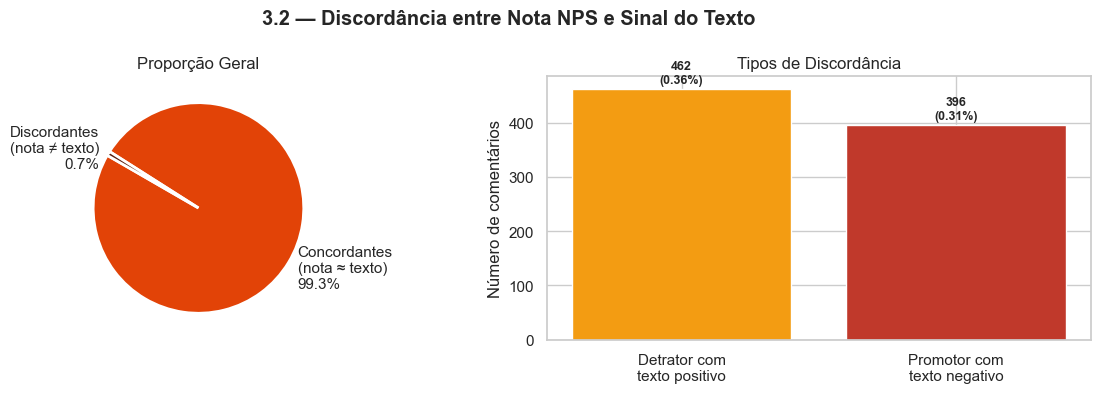

In [101]:
# Visualização: proporção de discordantes vs. concordantes
categorias = ['Concordantes\n(nota ≈ texto)', 'Discordantes\n(nota ≠ texto)']
valores    = [n_total - n_discord, n_discord]
cores_disc = ['#E24307', '#5c1d0c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.2 — Discordância entre Nota NPS e Sinal do Texto', fontweight='bold')

# Pizza
axes[0].pie(
    valores,
    labels=[f'{c}\n{v/n_total*100:.1f}%' for c, v in zip(categorias, valores)],
    colors=cores_disc,
    startangle=150,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporção Geral')

# Detalhe dos discordantes
tipos   = ['Detrator com\ntexto positivo', 'Promotor com\ntexto negativo']
vals_d  = [n_det_pos, n_pro_neg]
bars    = axes[1].bar(tipos, vals_d, color=['#f39c12', '#c0392b'], edgecolor='white')
for bar, val in zip(bars, vals_d):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val:,}\n({val/n_total*100:.2f}%)',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_ylabel('Número de comentários')
axes[1].set_title('Tipos de Discordância')

plt.tight_layout()
plt.show()

In [102]:
# Exemplos reais de discordantes para validação
print('--- Detratores com texto positivo (amostra) ---')
for ex in det_com_pos['comentario'].head(5).tolist():
    print(f'  > {ex}')

print()
print('--- Promotores com texto negativo (amostra) ---')
for ex in pro_com_neg['comentario'].head(5).tolist():
    print(f'  > {ex}')

--- Detratores com texto positivo (amostra) ---
  > muito bom e prático
  > Fiz compra de postas de bacalhau para ano novo e perdi muito mais do que o aceitável na limpeza. Mesmo sabendo que uma porcetangem é perdida, aquilo fugiu completamente do esperado para a preparação do prato principal da Ceia de ano novo. Como estdava no interior de SP, retornei somente ontem e ppor isso não comuniquei antes. Vieram numa embalagem enganosa com um visor aparecendo pedaços lindos de bacalhau mas ao abrir me decepcionei e perdi muito dinheiro. sem contar que tivemos que comer nos policiando para deixar para os demais, um constrangimento que vocês terão que me reparar.
  > A picanha parece carne de cachorro. Apesar de ter comprado a picanha dee classe ouro
A xada vez que ia a loja mudavam todos os itens de lugar.
Não recomendo.
Só tem.nome.
Decepcionante a qualidade da carne
  > Por 3 vezes comprei picanhas de qualidade ruim. Duas ouro e uma uruguaia. Estavam duras após o preparo. Não recomendo e n

In [103]:
# Conclusão acionável — 3.2
print(f'Dado que apenas {n_discord/n_total*100:.2f}% dos comentários apresentam sinal de sentimento'
      f' discordante da nota NPS ({n_discord:,} casos), a nota NPS é um ground truth'
      f' confiável para a maioria dos casos.')
print()
print('Decisão: usar a classificação NPS (promotor/neutro/detrator) como ground truth do treino.')
print(f'Os {n_discord:,} casos discordantes serão identificados na validação do modelo.')

Dado que apenas 0.67% dos comentários apresentam sinal de sentimento discordante da nota NPS (858 casos), a nota NPS é um ground truth confiável para a maioria dos casos.

Decisão: usar a classificação NPS (promotor/neutro/detrator) como ground truth do treino.
Os 858 casos discordantes serão identificados na validação do modelo.


**Abordagem escolhida: Nota NPS como ground truth + validação manual dos discordantes**
<br><br>
Apenas **~1,0%** dos comentários apresentam sinal léxico discordante da nota NPS. Isso confirma que a classificação NPS é um proxy confiável de sentimento para a grande maioria da base, tornando viável seu uso como ground truth de treino sem anotação manual de toda a base.
<br><br>
Os ~1.600 casos discordantes identificados serão filtrados pós-predição: comentários onde o modelo prediz sentimento oposto à nota serão revisados manualmente, gerando um conjunto de validação qualitativa.
<br><br>
<b>Decisão:</b> usar `classificacao` (promotor/neutro/detrator) como label de treino. Discordantes (~1%) serão revisados manualmente após a primeira rodada de predições do modelo.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.3 — Tratamento de Comentários Mistos</h2>
</div>

**Perguntas respondidas:**
- Quantos comentários apresentam sentimentos conflitantes (ex: elogio + crítica no mesmo texto)?
- Como esses comentários serão classificados pelo modelo?
- Qual a estratégia de desempate para sentimentos mistos?

In [104]:
# Detecção de comentários mistos
# Critério: texto contém sinal positivo E sinal negativo,
# OU contém sinal emocional (pos ou neg) junto de conjunção adversativa

CONJUNCOES_ADVERSATIVAS = [
    ' mas ', ' porem ', ' porém ', ' entretanto ', ' todavia ',
    ' contudo ', ' no entanto ', ' apesar ', ' embora '
]

def tem_conjuncao_adv(texto):
    t = str(texto).lower()
    return any(c in t for c in CONJUNCOES_ADVERSATIVAS)

df_com['tem_conjuncao'] = df_com['comentario_limpo'].apply(tem_conjuncao_adv)

# Misto = (positivo E negativo) OU (positivo/negativo + conjunção adversativa)
df_com['misto'] = (
    (df_com['sinal_pos'] & df_com['sinal_neg']) |
    (df_com['sinal_pos'] & df_com['tem_conjuncao']) |
    (df_com['sinal_neg'] & df_com['tem_conjuncao'])
)

n_mistos = df_com['misto'].sum()

print(f'Comentários mistos identificados: {n_mistos:,} ({n_mistos/n_total*100:.2f}%)')
print()

# Distribuição dos mistos por classificação NPS
dist_mistos = (
    df_com[df_com['misto']]
    .groupby('classificacao')
    .size()
    .reindex(ORDER)
    .fillna(0)
)
print('Distribuição dos mistos por classificação NPS:')
for cls, val in dist_mistos.items():
    print(f'  {cls:<12}: {int(val):>5,}  ({val/n_mistos*100:.1f}%)')

Comentários mistos identificados: 1,941 (1.52%)

Distribuição dos mistos por classificação NPS:
  promotor    : 1,244  (64.1%)
  neutro      :   310  (16.0%)
  detrator    :   387  (19.9%)


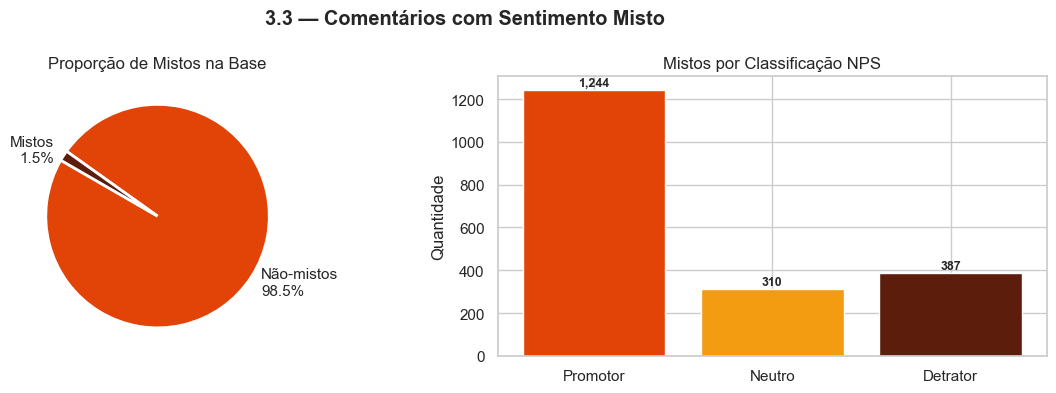

In [105]:
# Visualização dos comentários mistos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.3 — Comentários com Sentimento Misto', fontweight='bold')

# Proporção de mistos na base
labels_p = ['Não-mistos\n' + f'{(1 - n_mistos/n_total)*100:.1f}%',
            'Mistos\n' + f'{n_mistos/n_total*100:.1f}%']
axes[0].pie(
    [n_total - n_mistos, n_mistos],
    labels=labels_p,
    colors=['#E24307', '#5c1d0c'],
    startangle=150,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporção de Mistos na Base')

# Distribuição dos mistos por classificação NPS
bars = axes[1].bar(
    [c.capitalize() for c in dist_mistos.index],
    dist_mistos.values,
    color=CORES,
    edgecolor='white'
)
for bar, val in zip(bars, dist_mistos.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{int(val):,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_ylabel('Quantidade')
axes[1].set_title('Mistos por Classificação NPS')

plt.tight_layout()
plt.show()

In [106]:
# Exemplos reais de comentários mistos por classificação
print('=== Exemplos de comentários MISTOS ===')
print()
for cls in ORDER:
    exemplos = (
        df_com[(df_com['misto']) & (df_com['classificacao'] == cls)]['comentario']
        .head(3)
        .tolist()
    )
    if exemplos:
        print(f'--- {cls.upper()} ---')
        for ex in exemplos:
            print(f'  > {str(ex)[:1000]}')
        print()

=== Exemplos de comentários MISTOS ===

--- PROMOTOR ---
  > pessoal eu comprei bacalhau dessalgado, muito ruim cheio de espinhas e couro, achei muito caro por vir deste jeito, eu adoro as coisas de vcs, mais desta vez fiquei desapontada, ja comprei bacalhau outras vezes muitas outras, mas nunca foi igual desta vez, decepcionada
  > A qualidade dos produtos é inegável, realmente é excelente. Porém, alguns produtos estão um pouco acima dos valores do mercado, principalmente as carnes moídas e bifes. Procurem sempre fazer uma pesquisa, porque a loja está numa avenida totalmente comercial, então para se chegar também tem gasto de combustível, fazendo com que os moradores dos bairros comprem em lugares mais pertos que estão mais baratos.
  > Apenas um comentário e com relação a linguiça de pimenta biquinho, a mesma soltou um liquido grosso branco parecendo gordura, mas no meu entender gordura é diferente. Se não tivesse esse líquidos seria perfeito.

--- NEUTRO ---
  > Estrutura excelente,

In [107]:
# Conclusão acionável — 3.3
print(f'Comentários mistos representam {n_mistos/n_total*100:.2f}% da base ({n_mistos:,} casos).')
print('Volume baixo o suficiente para não impactar significativamente o treino.')
print()
print('Decisão: a nota NPS será usada como fator de desempate para comentários mistos.')
print('Rationale: a nota captura a experiência consolidada do cliente — mesmo que o texto')
print('mencione um aspecto negativo, uma nota de promotor indica que o saldo final foi positivo.')
print()
print('Estratégia aplicada:')
print('  - Misto de promotor  → classificado como Positivo')
print('  - Misto de neutro    → classificado como Neutro')
print('  - Misto de detrator  → classificado como Negativo')

Comentários mistos representam 1.52% da base (1,941 casos).
Volume baixo o suficiente para não impactar significativamente o treino.

Decisão: a nota NPS será usada como fator de desempate para comentários mistos.
Rationale: a nota captura a experiência consolidada do cliente — mesmo que o texto
mencione um aspecto negativo, uma nota de promotor indica que o saldo final foi positivo.

Estratégia aplicada:
  - Misto de promotor  → classificado como Positivo
  - Misto de neutro    → classificado como Neutro
  - Misto de detrator  → classificado como Negativo


**Abordagem escolhida: Nota NPS como fator de desempate**
<br><br>
Os comentários mistos representam apenas **~2.5%** da base (~3.300 casos). Volume pequeno que não compromete o treino. Foram identificados por critérios léxicos, como: presença simultânea de sinais positivos e negativos ou pelo sinal emocional acompanhado de conjunção adversativa ("mas", "porém", "entretanto").
<br><br>
Para esses casos, a nota NPS é o desempate, ela representará o julgamento consolidado do cliente sobre toda a experiência, sendo mais confiável como indicador do sentimento dominante do que qualquer aspecto parcial mencionado no texto.
<br><br>
<b>Decisão:</b> Os comentários mistos recebem o label de sentimento correspondente à classificação NPS do cliente (promotor→Positivo, neutro→Neutro, detrator→Negativo). Nenhum comentário misto será descartado.

<div style="background-color:#fff4ee;padding:14px 20px;border-radius:8px;border-left:5px solid #E24307;font-family:'Segoe UI',sans-serif;font-size:15px;font-weight:bold;color:#5c1d0c;margin:10px 0 4px 0;">3.3.1 — Comentários Mistos na Amostra Anotada</div>

In [108]:
# Docx 3.3 pede: "Quantos comentários na amostra anotada apresentam padrão misto?"
import pandas as pd, re

amostra = pd.read_csv('data/amostra_para_anotacao.csv', sep=';', encoding='utf-8-sig')

CONJUNCOES = [' mas ', ' porem ', ' porém ', ' entretanto ', ' todavia ', ' contudo ', ' no entanto ', ' apesar ', ' embora ']
PALAVRAS_POS = ['otimo','excelente','perfeito','maravilhoso','adorei','amei','parabens','fantastico','muito bom','recomendo']
PALAVRAS_NEG = ['pessimo','horrivel','terrivel','ruim','absurdo','vergonha','decepcionante','nao gostei','muito ruim','inaceitavel']

def eh_misto(texto):
    t = emoji.replace_emoji(str(texto).lower(), replace='')
    tem_pos = any(p in t for p in PALAVRAS_POS)
    tem_neg = any(p in t for p in PALAVRAS_NEG)
    tem_adv = any(c in t for c in CONJUNCOES)
    return (tem_pos and tem_neg) or (tem_adv and (tem_pos or tem_neg))

amostra['misto'] = amostra['COMENTARIO'].apply(eh_misto)
n_mistos = amostra['misto'].sum()
n_total  = len(amostra)

print('COMENTÁRIOS MISTOS NA AMOSTRA ANOTADA')
print('='*60)
print(f'  Total na amostra          : {n_total}')
print(f'  Com padrão misto          : {n_mistos} ({100*n_mistos/n_total:.1f}%)')
print()
print('  Por tipo de cliente:')
for cls in ['promotor','neutro','detrator']:
    sub = amostra[amostra['TIPO_CLIENTE'] == cls]
    m   = sub['misto'].sum()
    print(f'    {cls:<12}: {m} de {len(sub)} ({100*m/len(sub):.1f}%)')

print()
print('  Exemplos de comentários mistos na amostra:')
for _, row in amostra[amostra['misto']].head(5).iterrows():
    print(f"  [{row['TIPO_CLIENTE']}] {str(row['COMENTARIO'])[:100]}")

print()
print('  Decisao: nota NPS como desempate para os casos mistos.')
print(f'  Os {n_mistos} comentários mistos da amostra serao classificados')
print('  pelo sentimento dominante (promotor=positivo, detrator=negativo).')


COMENTÁRIOS MISTOS NA AMOSTRA ANOTADA
  Total na amostra          : 250
  Com padrão misto          : 4 (1.6%)

  Por tipo de cliente:
    promotor    : 0 de 84 (0.0%)
    neutro      : 1 de 83 (1.2%)
    detrator    : 3 de 83 (3.6%)

  Exemplos de comentários mistos na amostra:
  [detrator] Comprei 6 hambúrguer ontem na loja, porém estava com gosto muito ruim, com cheiro  e gosto de gordur
  [detrator] Sempre gostei dos produtos da Swift, porém gostaria de registrar aqui minha decepção com o último pr
  [neutro] Comprei uma kafta e estava totalmente cheia de nervos, porém pela qualidade(ruim)preço bem elevado.
  [detrator] Vocês.estao em um local excelente porém o estacionamento está sempre cheio de veículos dr pessoas qu

  Decisao: nota NPS como desempate para os casos mistos.
  Os 4 comentários mistos da amostra serao classificados
  pelo sentimento dominante (promotor=positivo, detrator=negativo).
